# Biosphere Size Model

**Hinkston et al., "Free Energy Budgets as Thermodynamic Constraints on Maximum Biosphere Size"**

In [1]:
import datetime
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman'], 'font.size': 12})


/Users/abradley/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Constants and Data

In [2]:
# Load constants
data_dir = Path("data")
plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)

with open(data_dir / "constants.json") as f:
    CONST = json.load(f)

G = CONST["G"]["value"]                    # 6.67430e-11 m^3 kg^-1 s^-2
k_B = CONST["k_B"]["value"]                # 1.380649e-23 J/K
L_sun = CONST["L_sun"]["value"]            # 3.828e26 W
t_sun = CONST["t_sun"]["value"]            # 4.60e9 years
k_gyr_to_s = CONST["k_gyr_to_s"]["value"]  # 3.15576e16 s/Gyr
T = CONST["T_surface"]["value"]            # 288 K

# Atmosphere-aware exergy and Arrhenius ISE constants
Ea_depurination = CONST["Ea_depurination"]["value"]  # 130000 J/mol
T_sun_eff = CONST["T_sun_eff"]["value"]              # 5778 K
R_sun_m = CONST["R_sun_m"]["value"]                  # 6.957e8 m (IAU 2015)
N_A = CONST["N_A"]["value"]                          # 6.022e23 mol^-1

# Convert Ea from J/mol to J/molecule for Arrhenius calculations
Ea_per_molecule = Ea_depurination / N_A  # ~2.16e-19 J

# Molar / cellular constants
N_A_INV = 1 / N_A                                    # mol (inverse Avogadro)
FG_PER_MOL_C = CONST["fg_per_mol_C"]["value"]        # 1.2e16 fg/mol
EARTH_SURFACE_CM2 = CONST["earth_surface_area_cm2"]["value"]  # 5.1e18 cm^2

# Genome / cell constants
ave_prokaryote = CONST["ave_prokaryote_genome_Mb"]["value"]  # 3.2147 Mb
cells_per_fg_C = 1 / CONST["carbon_per_cell_fg"]["value"]    # 1/86 cells/fg

# Modern biosphere (Landenmark et al. 2015)
modern_biosphere_Mb = CONST["modern_biosphere_Mb"]["value"]            # 5.3e31 Mb
modern_biosphere_Mb_error = CONST["modern_biosphere_Mb_error"]["value"]  # 3.6e31 Mb

# ISE (information-specific energy)
modern_biosphere_energy = CONST["ISE_empirical"]["value"]       # 1.67e-15 J/bit
modern_biosphere_energy_err = CONST["ISE_empirical_error"]["value"]  # 1.14e-15 J/bit

# Tidal parameters
k2_Q_rocky_icy = CONST["k2_Q_rocky_icy"]["value"]  # 0.006
k2_Q_giant = CONST["k2_Q_giant"]["value"]            # 3e-5

# Archean carbon flux bounds (mol/cm^2/yr)
ARCHEAN_CARBON_FLUX_MIN = CONST["archean_carbon_flux_min"]["value"]  # 1e6
ARCHEAN_CARBON_FLUX_MAX = CONST["archean_carbon_flux_max"]["value"]  # 1e10

# Proterozoic biomass bounds (fg C)
PROTEROZOIC_BIOMASS_MIN_FG = CONST["proterozoic_biomass_min_fg"]["value"]  # 9e30
PROTEROZOIC_BIOMASS_MAX_FG = CONST["proterozoic_biomass_max_fg"]["value"]  # 38.5e30

# Metabolic maintenance bounds
METABOLIC_POWER_MIN = CONST["metabolic_power_min_W_per_cell"]["value"]  # 1e-21 W/cell
METABOLIC_POWER_MAX = CONST["metabolic_power_max_W_per_cell"]["value"]  # 3e-19 W/cell
AVERAGE_CELL_LIFESPAN_YR = CONST["average_cell_lifespan_yr"]["value"]   # 1.9026e-5 yr

# --- Geological era boundaries [Gyr ago] ---
LIFE_ORIGIN_GYA = 3.8
ARCHEAN_END_GYA = 2.0
PHANEROZOIC_START_GYA = 0.4
GOE_GYA = 2.5
CAMBRIAN_START_GYA = 0.541
ACCRETION_OFFSET_GYR = 0.05

# Derived durations [Gyr]
ARCHEAN_DURATION_GYR = LIFE_ORIGIN_GYA - ARCHEAN_END_GYA       # 1.8
PROTEROZOIC_DURATION_GYR = ARCHEAN_END_GYA - PHANEROZOIC_START_GYA  # 1.6
PHANEROZOIC_DURATION_GYR = PHANEROZOIC_START_GYA                # 0.4

# Unit conversions
BITS_PER_MB = 2e6
GYR_TO_YR = 1e9
SEC_PER_YR = k_gyr_to_s / GYR_TO_YR
LOOKBACK_OFFSET_GYR = 4.55
TIME_STEPS = 1000

# Load data files
df_ss = pd.read_csv(data_dir / "solar_system_bodies.csv")
df_exo = pd.read_csv(data_dir / "exoplanet_data.csv", comment="#",low_memory=False)
subset_cols = ["pl_rade", "pl_orbsmax", "pl_orbeccen", "st_mass", "st_lum", "st_age","pl_masse"]
df_exo_f = df_exo.dropna(subset=subset_cols)
df_exo_f = df_exo_f[df_exo_f["sy_snum"] == 1]
#remove duplicates. Duplicates exist in the exoplanet database because there is a line entry per publication
df_exo_f = df_exo_f.drop_duplicates(subset=["pl_name"], keep="first")

print(f"Total exoplanets: {len(df_exo)}; total after filtering: {len(df_exo_f)}")
df_frank = pd.read_csv(data_dir / "frank_heating_rates.csv", comment="#")
df_tidal = pd.read_csv(data_dir / "tidal_parameters.csv")

with open(data_dir / "radiogenic_isotope_params.json") as f:
    ISOTOPES = json.load(f)

print(f"Loaded {len(df_ss)} SS bodies, {len(df_exo_f)} exoplanets, "
      f"{len(df_frank)} heating rate entries, {len(df_tidal)} tidal pairs")
print(f"New columns in SS data: {[c for c in df_ss.columns if 'T_' in c]}")
print(f"Ea (depurination) = {Ea_depurination:.0f} J/mol = {Ea_per_molecule:.3e} J/molecule")
print(f"T_sun_eff = {T_sun_eff} K")

Total exoplanets: 39506; total after filtering: 579
Loaded 28 SS bodies, 579 exoplanets, 125 heating rate entries, 48 tidal pairs
New columns in SS data: ['T_surface_K', 'T_bio_K']
Ea (depurination) = 130000 J/mol = 2.159e-19 J/molecule
T_sun_eff = 5778 K


In [3]:
# Time grid
time_values = np.linspace(0, 4.6, TIME_STEPS)

# Frank et al. heating rate lookup arrays
age_today = df_frank["age_Gyr"].tolist()
heating_rates = {
    "K40": df_frank["k40_W_per_kg"].tolist(),
    "Th232": df_frank["th232_W_per_kg"].tolist(),
    "U235": df_frank["u235_W_per_kg"].tolist(),
    "U238": df_frank["u238_W_per_kg"].tolist(),
}

# Decay constants from radiogenic_isotope_params.json (lambda = ln(2) / T_1/2)
decay_constants = {
    "K40": math.log(2) / ISOTOPES["isotopes"]["K40"]["half_life_Gyr"],
    "U238": math.log(2) / ISOTOPES["isotopes"]["U238"]["half_life_Gyr"],
    "U235": math.log(2) / ISOTOPES["isotopes"]["U235"]["half_life_Gyr"],
    "Th232": math.log(2) / ISOTOPES["isotopes"]["Th232"]["half_life_Gyr"],
}

# Bundle radiogenic parameters for explicit passing to functions
RAD_PARAMS = {
    "age_today": age_today,
    "heating_rates": heating_rates,
    "decay_constants": decay_constants,
}

print(f"Decay constants (1/Gyr): K40={decay_constants['K40']:.6f}, "
      f"U238={decay_constants['U238']:.6f}, U235={decay_constants['U235']:.6f}, "
      f"Th232={decay_constants['Th232']:.6f}")

Decay constants (1/Gyr): K40=0.554518, U238=0.155136, U235=0.984864, Th232=0.049334


## Biosphere History Model

In [4]:
# Biosphere size estimates by era
# Units: bits/yr for instantaneous, bit-years for cumulative

# --- Archean: from carbon flux estimates ---
# Carbon flux (mol/cm^2/yr) -> cells/yr -> bits/yr
min_cells_archean = (ARCHEAN_CARBON_FLUX_MIN * N_A_INV * EARTH_SURFACE_CM2
                     * SEC_PER_YR * FG_PER_MOL_C * cells_per_fg_C)
max_cells_archean = (ARCHEAN_CARBON_FLUX_MAX * N_A_INV * EARTH_SURFACE_CM2
                     * SEC_PER_YR * FG_PER_MOL_C * cells_per_fg_C)

min_archean_bits = min_cells_archean * ave_prokaryote * BITS_PER_MB
max_archean_bits = max_cells_archean * ave_prokaryote * BITS_PER_MB
ave_archean_bits = (min_archean_bits + max_archean_bits) / 2

a_min = ARCHEAN_DURATION_GYR * min_archean_bits * GYR_TO_YR * SEC_PER_YR
a_max = ARCHEAN_DURATION_GYR * max_archean_bits * GYR_TO_YR * SEC_PER_YR
a_ave = ARCHEAN_DURATION_GYR * ave_archean_bits * GYR_TO_YR * SEC_PER_YR

# --- Proterozoic: from biomass estimates ---
pro_min_carbon = PROTEROZOIC_BIOMASS_MIN_FG * cells_per_fg_C
pro_max_carbon = PROTEROZOIC_BIOMASS_MAX_FG * cells_per_fg_C
pro_ave_carbon = (pro_min_carbon + pro_max_carbon) / 2

min_pro_bits = pro_min_carbon * ave_prokaryote * BITS_PER_MB
max_pro_bits = pro_max_carbon * ave_prokaryote * BITS_PER_MB
ave_pro_bits = pro_ave_carbon * ave_prokaryote * BITS_PER_MB

p_min = PROTEROZOIC_DURATION_GYR * min_pro_bits * GYR_TO_YR * SEC_PER_YR
p_max = PROTEROZOIC_DURATION_GYR * max_pro_bits * GYR_TO_YR * SEC_PER_YR
p_ave = PROTEROZOIC_DURATION_GYR * ave_pro_bits * GYR_TO_YR * SEC_PER_YR

# --- Phanerozoic: from Landenmark et al. 2015 ---
landenmark_ave = modern_biosphere_Mb * BITS_PER_MB        # bits/yr
landenmark_error = modern_biosphere_Mb_error * BITS_PER_MB
landenmark_min = landenmark_ave - landenmark_error
landenmark_max = landenmark_ave + landenmark_error

m_min = landenmark_min * PHANEROZOIC_DURATION_GYR * GYR_TO_YR * SEC_PER_YR
m_max = landenmark_max * PHANEROZOIC_DURATION_GYR * GYR_TO_YR * SEC_PER_YR
m_ave = landenmark_ave * PHANEROZOIC_DURATION_GYR * GYR_TO_YR * SEC_PER_YR

min_total = a_min + p_min + m_min
max_total = a_max + p_max + m_max
ave_total = a_ave + p_ave + m_ave

# --- Metabolic maintenance bounds ---
min_metabolic = (METABOLIC_POWER_MIN / (ave_prokaryote * BITS_PER_MB)
                 * SEC_PER_YR * AVERAGE_CELL_LIFESPAN_YR)
max_metabolic = (METABOLIC_POWER_MAX / (ave_prokaryote * BITS_PER_MB)
                 * SEC_PER_YR * AVERAGE_CELL_LIFESPAN_YR)
ave_metabolic = (min_metabolic + max_metabolic) / 2

## Energy Calculation Functions

## Temperature-Dependent ISE (Arrhenius Model)

The information-specific energy depends on temperature through two competing effects:
1. The Landauer cost per erasure: $k_B T \ln 2$ (linear in T)
2. The damage rate requiring erasure: $r_{\text{damage}}(T) = A \exp(-E_a / k_B T)$ (Arrhenius)

We calibrate the pre-exponential factor $A$ so that ISE(288 K) = 1.67 × 10⁻¹⁵ J/bit (empirical Earth value).

In [5]:
def compute_ise_temperature(T_bio: float, Ea: float = Ea_per_molecule,
                              ISE_ref: float = modern_biosphere_energy,
                              T_ref: float = 288.0) -> dict:
    """Compute temperature-dependent ISE using Arrhenius damage model.

    ISE(T) = r_damage(T) * k_B * T * ln(2)
    r_damage(T) = A * exp(-Ea / (k_B * T))

    The pre-exponential A is calibrated so ISE(T_ref) = ISE_ref.

    Parameters
    ----------
    T_bio : float, biosphere operating temperature [K]
    Ea : float, activation energy per molecule [J]
    ISE_ref : float, empirical ISE at T_ref [J/bit]
    T_ref : float, reference temperature [K]

    Returns
    -------
    dict with ISE, r_damage, landauer_cost, ratio_to_earth, A_calibrated
    """
    # Landauer cost at reference temperature
    landauer_ref = k_B * T_ref * np.log(2)

    # Calibrate A: ISE_ref = A * exp(-Ea/(k_B*T_ref)) * k_B * T_ref * ln(2)
    # => A = ISE_ref / (exp(-Ea/(k_B*T_ref)) * k_B * T_ref * ln(2))
    r_damage_ref = ISE_ref / landauer_ref  # damage rate at T_ref (per-bit per-lifetime)
    A_calibrated = r_damage_ref / np.exp(-Ea / (k_B * T_ref))

    # Compute at T_bio
    landauer_T = k_B * T_bio * np.log(2)
    r_damage_T = A_calibrated * np.exp(-Ea / (k_B * T_bio))
    ISE_T = r_damage_T * landauer_T

    return {
        "ISE": ISE_T,
        "r_damage": r_damage_T,
        "landauer_cost": landauer_T,
        "ratio_to_earth": ISE_T / ISE_ref,
        "A_calibrated": A_calibrated,
    }


def petela_exergy_fraction(T_cold: float, T_hot: float) -> float:
    """Petela formula for maximum work from thermal radiation.

    eta = 1 - (4/3)(T_c/T_h) + (1/3)(T_c/T_h)^4

    Parameters
    ----------
    T_cold : float, cold reservoir temperature [K]
    T_hot : float, hot source temperature [K]

    Returns
    -------
    float : exergy fraction (0 to 1)
    """
    ratio = T_cold / T_hot
    return 1.0 - (4.0 / 3.0) * ratio + (1.0 / 3.0) * ratio**4


def press_diffuse_exergy_fraction(T_cold: float, T_hot: float,
                                  star_radius_m: float,
                                  distance_m: float) -> float:
    """Press 1976 / Landsberg-Tonge 1979/1980 dilute-radiation exergy bound.

    For a non-concentrating absorber receiving radiation that is averaged over
    the local sky (e.g., the surface of a body with an atmosphere that
    scatters direct beam into diffuse radiation), the exergy fraction is
    tighter than Petela because the dilute photon field has higher entropy
    per unit energy than a full-hemisphere blackbody.

    eta_diffuse = 1 - (4/3) * X(epsilon) * (T_c / T_h)

    where epsilon = (R_star)^2 / (4 * d^2) is the dilution factor (the
    fraction of 4*pi solid angle subtended by the star's disk at distance d),
    and the Landsberg-Tonge entropy-correction factor (small-epsilon
    approximation, Eq A.11) is

    X(epsilon) = 0.9652 + 0.2777 * ln(1 / epsilon) + 0.0511 * epsilon.

    The approximation is derived analytically from the integral form
    (Eq 8.13 of Landsberg & Tonge 1980) for emissivities below ~0.1; our
    Solar System and exoplanet dilution factors range from ~10^-4 to
    ~10^-9, well within validity.

    References
    ----------
    Press, W. H. (1976) "Theoretical maximum for energy from direct and
    diffuse sunlight." Nature 264, 734-735.
    Landsberg, P. T. & Tonge, G. (1980) "Thermodynamic energy conversion
    efficiencies." J. Appl. Phys. 51, R1-R20.

    Parameters
    ----------
    T_cold : float, biosphere/sink temperature [K]
    T_hot  : float, source (star) effective temperature [K]
    star_radius_m : float, star's physical radius [m]
    distance_m    : float, body's heliocentric distance [m]

    Returns
    -------
    float : exergy fraction (0 to 1)
    """
    epsilon = (star_radius_m / (2.0 * distance_m)) ** 2
    if epsilon >= 1.0:
        # Within a stellar radius: dilute formula doesn't apply; fall back to Petela
        return petela_exergy_fraction(T_cold, T_hot)
    X_eps = 0.9652 + 0.2777 * np.log(1.0 / epsilon) + 0.0511 * epsilon
    return 1.0 - (4.0 / 3.0) * X_eps * (T_cold / T_hot)


def carnot_efficiency(T_cold: float, T_hot: float) -> float:
    """Carnot efficiency for heat engine.

    Parameters
    ----------
    T_cold : float, cold reservoir temperature [K]
    T_hot : float, hot reservoir temperature [K]

    Returns
    -------
    float : maximum efficiency (0 to 1)
    """
    if T_hot <= T_cold:
        return 0.0
    return 1.0 - T_cold / T_hot


def compute_free_energy_budget(raw_budget: dict, T_bio: float,
                                T_mantle: float = 1600.0,
                                star_radius_m: float | None = None,
                                distance_m: float | None = None,
                                star_T_eff: float | None = None,
                                has_atmosphere: bool = False) -> dict:
    """Convert raw energy budget to free energy budget.

    Applies source-specific exergy conversions:
    - Solar: Petela formula (~93% for Sun)
    - Tidal: ~100% (mechanical work)
    - Radiogenic: Carnot-limited (T_hot = mantle, T_cold = T_bio)
    - Accretional: 0% (transient, excluded from free energy)

    Parameters
    ----------
    raw_budget : dict, output from compute_body_energy_budget()
    T_bio : float, biosphere operating temperature [K]
    T_mantle : float, mantle/core temperature for Carnot calc [K]

    Returns
    -------
    dict with free energy by source, total, efficiencies, entropy export rate
    """
    # Solar exergy: compute BOTH bounds; select headline by atmospheric state.
    # - Petela (concentrating-absorber bound, direct beam at full source temperature):
    #   appropriate for airless bodies whose surfaces receive unscattered solar beam.
    # - Press 1976 / Landsberg-Tonge 1979/1980 diffuse bound (non-concentrating absorber
    #   averaging over local sky): appropriate for atmospheric bodies whose surface
    #   absorbers see scattered radiation with elevated entropy per energy.
    T_h_solar = star_T_eff if star_T_eff is not None else T_sun_eff
    eta_solar_petela = petela_exergy_fraction(T_bio, T_h_solar)
    F_solar_petela = raw_budget["solar_energy"] * eta_solar_petela
    if star_radius_m is not None and distance_m is not None and distance_m > 0:
        eta_solar_diffuse = press_diffuse_exergy_fraction(
            T_bio, T_h_solar, star_radius_m, distance_m
        )
    else:
        # Without distance/radius info, no dilution correction available.
        eta_solar_diffuse = eta_solar_petela
    F_solar_diffuse = raw_budget["solar_energy"] * eta_solar_diffuse
    # Headline depends on atmospheric scattering state
    if has_atmosphere:
        eta_solar = eta_solar_diffuse
        F_solar = F_solar_diffuse
    else:
        eta_solar = eta_solar_petela
        F_solar = F_solar_petela

    # Tidal: mechanical work, eta ~ 1.0
    eta_tidal = 1.0
    F_tidal = raw_budget["tidal_energy"] * eta_tidal

    # Radiogenic: Carnot-limited
    eta_radiogenic = carnot_efficiency(T_bio, T_mantle)
    F_radiogenic = raw_budget["radiogenic_energy"] * eta_radiogenic

    # Accretional: transient, excluded
    eta_accretional = 0.0
    F_accretional = 0.0

    F_total = F_solar + F_tidal + F_radiogenic + F_accretional
    F_total_petela = F_solar_petela + F_tidal + F_radiogenic + F_accretional
    F_internal = F_tidal + F_radiogenic + F_accretional

    # Entropy export rate (using free energy power over system age)
    # S_dot = P_free / T_bio where P_free = F_total / t
    # We report F_total and T_bio; S_dot computed downstream

    # Effective overall exergy fraction
    E_total_raw = raw_budget["total"]
    eta_effective = F_total / E_total_raw if E_total_raw > 0 else 0.0

    return {
        "F_solar": F_solar,
        "F_solar_petela": F_solar_petela,
        "F_solar_diffuse": F_solar_diffuse,
        "F_tidal": F_tidal,
        "F_radiogenic": F_radiogenic,
        "F_accretional": F_accretional,
        "F_total": F_total,
        "F_total_petela": F_total_petela,
        "F_internal": F_internal,
        "eta_solar": eta_solar,
        "eta_solar_petela": eta_solar_petela,
        "eta_solar_diffuse": eta_solar_diffuse,
        "eta_tidal": eta_tidal,
        "eta_radiogenic": eta_radiogenic,
        "eta_accretional": eta_accretional,
        "eta_effective": eta_effective,
    }


# Verify calibration
ise_check = compute_ise_temperature(288.0)
print(f"ISE(288 K) = {ise_check['ISE']:.3e} J/bit (should be {modern_biosphere_energy:.3e})")
print(f"A (calibrated) = {ise_check['A_calibrated']:.3e} (damage events per bit per lifetime)")
print(f"r_damage(288 K) = {ise_check['r_damage']:.3e}")
print(f"Landauer cost(288 K) = {ise_check['landauer_cost']:.3e} J/bit")
print()

# Petela check for Sun
eta_sun_earth = petela_exergy_fraction(288.0, T_sun_eff)
print(f"Petela exergy fraction (Sun, T_cold=288 K): {eta_sun_earth:.4f} ({eta_sun_earth*100:.1f}%)")

# ISE at selected temperatures
for T_test in [72, 100, 176, 250, 270, 273, 288, 440, 735]:
    result = compute_ise_temperature(float(T_test))
    print(f"  ISE({T_test} K) = {result['ISE']:.3e} J/bit, "
          f"ratio to Earth = {result['ratio_to_earth']:.3e}")

ISE(288 K) = 1.670e-15 J/bit (should be 1.670e-15)
A (calibrated) = 2.294e+29 (damage events per bit per lifetime)
r_damage(288 K) = 6.059e+05
Landauer cost(288 K) = 2.756e-21 J/bit

Petela exergy fraction (Sun, T_cold=288 K): 0.9335 (93.4%)
  ISE(72 K) = 7.691e-87 J/bit, ratio to Earth = 4.605e-72
  ISE(100 K) = 2.731e-60 J/bit, ratio to Earth = 1.635e-45
  ISE(176 K) = 1.010e-30 J/bit, ratio to Earth = 6.051e-16
  ISE(250 K) = 3.779e-19 J/bit, ratio to Earth = 2.263e-04
  ISE(270 K) = 4.196e-17 J/bit, ratio to Earth = 2.512e-02
  ISE(273 K) = 8.016e-17 J/bit, ratio to Earth = 4.800e-02
  ISE(288 K) = 1.670e-15 J/bit, ratio to Earth = 1.000e+00
  ISE(440 K) = 3.564e-07 J/bit, ratio to Earth = 2.134e+08
  ISE(735 K) = 9.312e-01 J/bit, ratio to Earth = 5.576e+14


In [6]:
def suns_free_energy(radius: float, distance: float, albedo: float,
                     time_sheet: float,
                     L_sun_val: float = L_sun, t_sun_val: float = t_sun,
                     k_gyr_to_s_val: float = k_gyr_to_s) -> float:
    """Cumulative solar energy with Gough (1981) luminosity evolution.
    
    Integrates the Gough (1981) main-sequence luminosity model:
        L(t) = L_sun / (1 + (2/5)(1 - t/t_0))
    
    Analytical result for intercepted flux (1-A)*R^2/(4*d^2) integrated from
    t = ACCRETION_OFFSET_GYR to t = time_sheet:
        E = (5/2) * L_sun * t_0 * R^2 * (1-A) * k / (4*d^2) *
            [ln|2*0.05 - 7*t_0| - ln|2*t - 7*t_0|]
    
    Parameters
    ----------
    radius : float, planetary radius [m]
    distance : float, orbital distance [m]
    albedo : float, Bond albedo
    time_sheet : float, star age [Gyr]
    L_sun_val : float, solar luminosity [W]
    t_sun_val : float, solar age [yr]
    k_gyr_to_s_val : float, Gyr-to-seconds conversion
    
    Returns
    -------
    float : cumulative intercepted solar energy [J]
    """
    t_0_Gyr = t_sun_val / GYR_TO_YR
    r = float(radius)
    d = float(distance)
    A = float(albedo)
    t = float(time_sheet)
    
    prefactor = (5 / 2) * L_sun_val * t_0_Gyr * r**2 * (1 - A) * k_gyr_to_s_val / (4 * d**2)
    # Integration constant: E(ACCRETION_OFFSET_GYR) = 0
    C = prefactor * np.log(abs(2 * ACCRETION_OFFSET_GYR - 7 * t_0_Gyr))
    E = -prefactor * np.log(abs(2 * t - 7 * t_0_Gyr)) + C
    return E


def solar_free_energy(radius: float, distance: float, albedo: float,
                      time_sheet: float, luminosity: float) -> float:
    """Cumulative solar energy with constant luminosity.
    
    Used for exoplanets where stellar evolution model is not available.
    
    Parameters
    ----------
    radius : float, planetary radius [m]
    distance : float, orbital distance [m]
    albedo : float, Bond albedo
    time_sheet : float, integration time [Gyr]
    luminosity : float, stellar luminosity [W]
    
    Returns
    -------
    float : cumulative intercepted solar energy [J]
    """
    return (float(luminosity) * float(radius)**2 * k_gyr_to_s
            * (1 - float(albedo)) * float(time_sheet) / (4 * float(distance)**2))


def compute_tidal_power(M_primary: float, R_body: float, k2_Q: float,
                        semi_major_axis: float, eccentricity: float,
                        orbital_period_s: float) -> float:
    """Compute instantaneous tidal dissipation power.
    
    P_tidal = (21/2) * (k2/Q) * G * M_p^2 * R_s^5 * omega * e^2 / a^6
    
    Parameters
    ----------
    M_primary : float, mass of the primary body [kg]
    R_body : float, radius of the tidally heated body [m]
    k2_Q : float, tidal Love number / quality factor ratio
    semi_major_axis : float, orbital semi-major axis [m]
    eccentricity : float, orbital eccentricity
    orbital_period_s : float, orbital period [s]
    
    Returns
    -------
    float : tidal power [W]
    """
    if eccentricity == 0 or pd.isna(eccentricity) or semi_major_axis == 0 or pd.isna(semi_major_axis):
        return 0.0
    omega = 2 * np.pi / orbital_period_s
    return (21 / 2) * k2_Q * G * M_primary**2 * R_body**5 * omega * eccentricity**2 / semi_major_axis**6


def get_heating_index(star_age: float, rad_params: dict = None) -> int:
    """Find index in Frank et al. heating rate lookup table for a given star age.
    
    Parameters
    ----------
    star_age : float, system age [Gyr]
    rad_params : dict, radiogenic parameters (uses global RAD_PARAMS if None)
    """
    if rad_params is None:
        rad_params = RAD_PARAMS
    ages = rad_params["age_today"]
    rounded = math.ceil(star_age * 10) / 10.0
    try:
        return ages.index(rounded)
    except ValueError:
        if rounded > ages[0]:
            return 0
        if rounded < ages[-1]:
            return len(ages) - 1
        diffs = [abs(a - rounded) for a in ages]
        return diffs.index(min(diffs))


def compute_radiogenic_energy(mass: float, star_age: float,
                              rad_params: dict = None,
                              integration_time: float = None) -> float:
    """Compute cumulative radiogenic energy for a body.
    
    Uses Frank et al. present-day heating rates (W/kg) with backward
    integration: rate * (1/lambda) * (exp(lambda*t) - 1).
    
    This is algebraically equivalent to the manuscript's Eq. 6, which uses
    the Turcotte & Schubert convention of initial concentrations with forward
    integration: H * C_0 * (1/lambda) * (1 - exp(-lambda*t)).  The two forms
    are identical because C_initial = c_present * exp(lambda*t), so
    c_present * (exp(lambda*t) - 1) = C_initial * (1 - exp(-lambda*t)).
    
    Parameters
    ----------
    mass : float, body mass [kg]
    star_age : float, system age [Gyr] (used to look up heating rates)
    rad_params : dict, radiogenic parameters (uses global RAD_PARAMS if None)
    integration_time : float, integration duration [Gyr] (defaults to star_age)
    
    Returns
    -------
    float : cumulative radiogenic energy [J]
    """
    if rad_params is None:
        rad_params = RAD_PARAMS
    if integration_time is None:
        integration_time = star_age
    
    idx = get_heating_index(star_age, rad_params)
    hr = rad_params["heating_rates"]
    dc = rad_params["decay_constants"]
    
    total = 0.0
    for isotope, hr_key in [("K40", "K40"), ("Th232", "Th232"),
                             ("U235", "U235"), ("U238", "U238")]:
        rate = hr[hr_key][idx]
        lam = dc[isotope]
        total += rate * (1 / lam) * k_gyr_to_s * (np.exp(lam * integration_time) - 1) * mass
    
    return total


def compute_body_energy_budget(mass: float, radius: float, distance: float,
                               albedo: float, star_age: float,
                               tidal_energy: float,
                               solar_func, solar_func_kwargs: dict = None,
                               rad_params: dict = None) -> dict:
    """Compute complete energy budget for a planetary body.
    
    Unifies the SS and exoplanet energy loops into a single function.
    
    Parameters
    ----------
    mass : float, body mass [kg]
    radius : float, body radius [m]
    distance : float, orbital distance [m]
    albedo : float, Bond albedo
    star_age : float, system age [Gyr]
    tidal_energy : float, cumulative tidal energy [J]
    solar_func : callable, function to compute solar energy
    solar_func_kwargs : dict, extra kwargs for solar_func (e.g. luminosity)
    rad_params : dict, radiogenic parameters
    
    Returns
    -------
    dict with keys: accretional_energy, radiogenic_energy, solar_energy,
                    tidal_energy, total_internal, total, max_info
    """
    if solar_func_kwargs is None:
        solar_func_kwargs = {}
    
    accretional_energy = (3 / 5) * G * mass**2 / radius
    radiogenic_energy = compute_radiogenic_energy(mass, star_age, rad_params)
    solar_energy = solar_func(radius, distance, albedo, star_age, **solar_func_kwargs)
    
    total_internal = radiogenic_energy + tidal_energy + accretional_energy
    total = total_internal + solar_energy
    max_info = total / (k_B * T * np.log(2))
    
    return {
        "accretional_energy": accretional_energy,
        "radiogenic_energy": radiogenic_energy,
        "solar_energy": solar_energy,
        "tidal_energy": tidal_energy,
        "total_internal": total_internal,
        "total": total,
        "max_info": max_info,
    }

In [7]:
def calculate_biosphere_size(lookback_gyr: float, num_years: float) -> tuple:
    """Calculate cumulative biosphere size (bits) at a given lookback time.
    
    Assigns era-appropriate instantaneous biosphere sizes and accumulates
    them over elapsed time, transitioning at era boundaries.
    
    Parameters
    ----------
    lookback_gyr : float, time before present [Gyr]
    num_years : float, elapsed time since origin of life [yr]
    
    Returns
    -------
    tuple of (min, max, ave) cumulative biosphere size [bits]
    """
    archean_yr     = ARCHEAN_DURATION_GYR * GYR_TO_YR
    proterozoic_yr = PROTEROZOIC_DURATION_GYR * GYR_TO_YR
    if lookback_gyr > ARCHEAN_END_GYA:
        return (min_archean_bits * num_years,
                max_archean_bits * num_years,
                ave_archean_bits * num_years)
    elif lookback_gyr > PHANEROZOIC_START_GYA:
        # In Proterozoic: Archean contribution fixed at its full duration;
        # Proterozoic rate accrues only over elapsed time within Proterozoic.
        pro_elapsed = num_years - archean_yr
        return (min_pro_bits * pro_elapsed + min_archean_bits * archean_yr,
                max_pro_bits * pro_elapsed + max_archean_bits * archean_yr,
                ave_pro_bits * pro_elapsed + ave_archean_bits * archean_yr)
    else:
        # In Phanerozoic: Archean + Proterozoic contributions fixed;
        # modern rate accrues only over elapsed time within Phanerozoic.
        phan_elapsed = num_years - archean_yr - proterozoic_yr
        return (landenmark_min * phan_elapsed + min_archean_bits * archean_yr + min_pro_bits * proterozoic_yr,
                landenmark_max * phan_elapsed + max_archean_bits * archean_yr + max_pro_bits * proterozoic_yr,
                landenmark_ave * phan_elapsed + ave_archean_bits * archean_yr + ave_pro_bits * proterozoic_yr)


def calculate_energy_requirements(biosphere_size: tuple) -> tuple:
    """Calculate energy requirements from biosphere size.
    
    Computes both thermodynamic minimum (Landauer + metabolic maintenance)
    and empirical ISE energy requirements.
    
    Parameters
    ----------
    biosphere_size : tuple of (min, max, ave) biosphere size [bits]
    
    Returns
    -------
    tuple of (E_min, E_max, E_ave, E_all_min, E_all_max, E_all_ave) [J]
    """
    E_min = (k_B * T * np.log(2) + min_metabolic) * biosphere_size[0]
    E_max = (k_B * T * np.log(2) + max_metabolic) * biosphere_size[1]
    E_ave = (k_B * T * np.log(2) + ave_metabolic) * biosphere_size[2]
    E_all_min = biosphere_size[0] * (modern_biosphere_energy - modern_biosphere_energy_err)
    E_all_max = biosphere_size[1] * (modern_biosphere_energy + modern_biosphere_energy_err)
    E_all_ave = biosphere_size[2] * modern_biosphere_energy
    return E_min, E_max, E_ave, E_all_min, E_all_max, E_all_ave

## Build Tidal Power Lookup from Parameters

In [8]:
# Build a lookup: body name -> tidal power (computed from first principles)
# Some bodies are tidally heated by their primary (e.g., Moon by Earth)
# Some bodies also cause tides on their primary (e.g., Moon causes tides on Earth)
# We want the power dissipated IN the body (body as orbiter)

tidal_power_lookup = {}
tidal_energy_lookup = {}

for _, row in df_tidal.iterrows():
    orbiter = row["orbiter"]
    orbitee = row["orbitee"]
    
    M_primary = float(row["orbitee_mass_kg"])
    R_body = float(row["orbiter_radius_m"])
    k2Q = float(row["k2_Q_est"])
    sma = float(row["semi_major_axis_m"])
    ecc = float(row["eccentricity"])
    period_s = float(row["orbital_period_s"])
    age_s = float(row["age_s"])
    
    P = compute_tidal_power(M_primary, R_body, k2Q, sma, ecc, period_s)
    E = P * age_s
    
    # Use lowercase for lookup consistency
    key = orbiter.lower()
    if key not in tidal_power_lookup:
        tidal_power_lookup[key] = 0.0
        tidal_energy_lookup[key] = 0.0
    tidal_power_lookup[key] += P
    tidal_energy_lookup[key] += E

# Verify against known values
print("Tidal power spot-checks:")
for body in ["Moon", "Io", "Europa", "Enceladus", "Titan"]:
    key = body.lower()
    if key in tidal_power_lookup:
        print(f"  {body}: P_tidal = {tidal_power_lookup[key]:.3e} W, E_tidal = {tidal_energy_lookup[key]:.3e} J")

Tidal power spot-checks:
  Moon: P_tidal = 5.922e+09 W, E_tidal = 8.498e+26 J
  Io: P_tidal = 3.560e+13 W, E_tidal = 5.108e+30 J
  Europa: P_tidal = 2.566e+12 W, E_tidal = 3.682e+29 J
  Enceladus: P_tidal = 9.964e+09 W, E_tidal = 1.430e+27 J
  Titan: P_tidal = 1.796e+11 W, E_tidal = 2.578e+28 J


## Main Energy Budget Calculation

Solar System bodies use luminosity evolution (Gough 1981); exoplanets use constant present-day luminosity (NEA `st_lum` column converted from log to linear).

In [9]:
# Extract SS body arrays
names = df_ss["name"].tolist()
star_ages = df_ss["star_age_Gyr"].tolist()
radii = df_ss["radius_m"].tolist()
distances = df_ss["distance_m"].tolist()
albedos = df_ss["albedo"].tolist()
masses = df_ss["mass_kg"].tolist()
luminosities = df_ss["luminosity_W"].tolist()
T_bio_values = df_ss["T_bio_K"].tolist()
T_surface_values = df_ss["T_surface_K"].tolist()

EARTH_IDX = names.index("Earth")

# Results arrays (raw energy)
accretional_energy_values = []
solar_free_energy_values = []
radiogenic_energy_values = []
tidal_energy_values = []
tidal_power_values = []
total_es = []
total_es_int = []
max_infos = []

# Free energy arrays
F_solar_values = []
F_solar_petela_values = []
F_solar_diffuse_values = []
F_tidal_values = []
F_radiogenic_values = []
F_total_values = []
F_total_petela_values = []
F_internal_values = []
eta_solar_petela_values = []
eta_solar_diffuse_values = []
eta_effective_values = []

# Body-specific ISE arrays
ISE_body_values = []
ISE_ratio_values = []

# Bodies treated as having an absorption-relevant atmosphere (direct beam scattered to
# diffuse by the time it is absorbed). For these we apply the Press 1976 / Landsberg-Tonge
# 1980 dilute-radiation exergy bound. All other Solar System bodies are treated as
# airless (radiation reaches absorbers as direct beam) and use Petela.
ATMOSPHERIC_BODIES = {"Earth", "Venus", "Titan"}

# Mantle temperatures for Carnot calculation (rough estimates)
# Terrestrial planets: ~1600-4000 K; icy moons: ~800-1200 K; giants: not applicable
MANTLE_TEMPS = {
    "Mercury": 1800, "Venus": 3000, "Earth": 1600, "Mars": 1500, "Moon": 1200,
    "Jupiter": 20000, "Saturn": 12000, "Uranus": 5000, "Neptune": 5000,
    "Io": 1200, "Europa": 800, "Ganymede": 800, "Callisto": 600,
    "Mimas": 400, "Enceladus": 600, "Tethys": 400, "Dione": 500,
    "Rhea": 500, "Titan": 800, "Iapetus": 400,
    "Miranda": 400, "Ariel": 500, "Umbriel": 400, "Titania": 500, "Oberon": 500,
    "Triton": 600, "Pluto": 400, "Charon": 300,
}

for i in range(len(names)):
    key = names[i].lower()
    tidal_e = tidal_energy_lookup.get(key, 0.0)
    tidal_p = tidal_power_lookup.get(key, 0.0)
    T_bio = T_bio_values[i]

    # Raw energy budget
    budget = compute_body_energy_budget(
        mass=masses[i], radius=radii[i], distance=distances[i],
        albedo=albedos[i], star_age=star_ages[i],
        tidal_energy=tidal_e,
        solar_func=suns_free_energy,
        rad_params=RAD_PARAMS,
    )

    accretional_energy_values.append(budget["accretional_energy"])
    solar_free_energy_values.append(budget["solar_energy"])
    radiogenic_energy_values.append(budget["radiogenic_energy"])
    tidal_energy_values.append(tidal_e)
    tidal_power_values.append(tidal_p)
    total_es.append(budget["total"])
    total_es_int.append(budget["total_internal"])
    max_infos.append(budget["max_info"])

    # Free energy budget
    T_mantle = MANTLE_TEMPS.get(names[i], 1000)
    fe_budget = compute_free_energy_budget(
        budget, T_bio, T_mantle=T_mantle,
        star_radius_m=R_sun_m,
        distance_m=distances[i],
        star_T_eff=T_sun_eff,
        has_atmosphere=names[i] in ATMOSPHERIC_BODIES,
    )
    F_solar_values.append(fe_budget["F_solar"])
    F_solar_petela_values.append(fe_budget["F_solar_petela"])
    F_solar_diffuse_values.append(fe_budget["F_solar_diffuse"])
    F_tidal_values.append(fe_budget["F_tidal"])
    F_radiogenic_values.append(fe_budget["F_radiogenic"])
    F_total_values.append(fe_budget["F_total"])
    F_total_petela_values.append(fe_budget["F_total_petela"])
    F_internal_values.append(fe_budget["F_internal"])
    eta_solar_petela_values.append(fe_budget["eta_solar_petela"])
    eta_solar_diffuse_values.append(fe_budget["eta_solar_diffuse"])
    eta_effective_values.append(fe_budget["eta_effective"])

    # Body-specific ISE
    ise_result = compute_ise_temperature(T_bio)
    ISE_body_values.append(ise_result["ISE"])
    ISE_ratio_values.append(ise_result["ratio_to_earth"])

print("Solar System body energy budgets computed (raw + free energy).")
print(f"Earth total raw energy: {total_es[EARTH_IDX]:.3e} J")
print(f"Earth free energy (F_total): {F_total_values[EARTH_IDX]:.3e} J")
print(f"Earth eta_effective: {eta_effective_values[EARTH_IDX]:.4f}")
print(f"Earth ISE(288 K): {ISE_body_values[EARTH_IDX]:.3e} J/bit")

Solar System body energy budgets computed (raw + free energy).
Earth total raw energy: 1.515e+34 J
Earth free energy (F_total): 1.063e+34 J
Earth eta_effective: 0.7016
Earth ISE(288 K): 1.670e-15 J/bit


## Exoplanet Energy Budgets

In [10]:
# Append exoplanet data to the same arrays
exo_names = df_exo_f["pl_name"].tolist()
exo_masses_arr = (df_exo_f["pl_masse"] * CONST["M_EARTH_KG"]["value"]).tolist() # kg
exo_radii_arr = (df_exo_f["pl_rade"] * CONST["R_EARTH_M"]["value"]).tolist() # m
exo_albedos_arr = [0.29] * len(df_exo_f) # default to earth albedo
exo_star_ages_arr = df_exo_f["st_age"].tolist() # Gyr
exo_lum_corrected = (10**df_exo_f["st_lum"] * CONST["L_sun"]["value"]).tolist() # W
exo_st_rad_arr = (df_exo_f["st_rad"] * R_sun_m).tolist()  # m, per-system stellar radius
exo_st_teff_arr = df_exo_f["st_teff"].tolist()  # K, per-system stellar effective temperature


# tidal calculation (SI units)
a_m_series = df_exo_f["pl_orbsmax"] * CONST["AU_TO_M"]["value"]
exo_sma_m_arr = a_m_series.tolist() # Distance from planet to star
omega = (2 * np.pi) / (df_exo_f["pl_orbper"] * 86400) # s^-1
st_mass_kg = df_exo_f["st_mass"] * CONST["MASS_SUN"]["value"] # kg
pl_rad_m = df_exo_f["pl_rade"] * CONST["R_EARTH_M"]["value"] # m

# Tidal Power Calculation
exo_tidal_power_series = (
    (21 / 2) * (k2_Q_rocky_icy) * (G * (st_mass_kg**2) * (pl_rad_m**5) * omega * (df_exo_f["pl_orbeccen"]**2)) / 
    (a_m_series**6)
) # W

star_age_s = df_exo_f["st_age"] * k_gyr_to_s # Gyr to s (canonical constant)
exo_tidal_e_series = exo_tidal_power_series * star_age_s
exo_tidal_e_arr = exo_tidal_e_series.tolist() # J

for i in range(len(exo_names)):
    # Handle NaNs in input data to prevent budget failure
    tidal_e = exo_tidal_e_arr[i] if not pd.isna(exo_tidal_e_arr[i]) else 0.0
    sma = exo_sma_m_arr[i] if not pd.isna(exo_sma_m_arr[i]) else 0.0
    age = exo_star_ages_arr[i] if not pd.isna(exo_star_ages_arr[i]) else 4.5 # Default to Earth/Solar age if missing
    
    # If orbital distance is missing, solar energy cannot be computed accurately
    if sma <= 0:
        continue

    budget = compute_body_energy_budget(
        mass=exo_masses_arr[i], 
        radius=exo_radii_arr[i],
        distance=sma,
        albedo=exo_albedos_arr[i],
        star_age=age,
        tidal_energy=tidal_e,
        solar_func=solar_free_energy,
        solar_func_kwargs={"luminosity": exo_lum_corrected[i]},
        rad_params=RAD_PARAMS,
    )
    
    names.append(exo_names[i])
    masses.append(exo_masses_arr[i])
    radii.append(exo_radii_arr[i])
    # IMPORTANT: We store 'sma' in the distances list so the summary table 
    # and histogram use the planet-to-star distance for the AU average.
    distances.append(sma) 
    albedos.append(exo_albedos_arr[i])
    star_ages.append(age)
    luminosities.append(exo_lum_corrected[i])
    
    accretional_energy_values.append(budget["accretional_energy"])
    solar_free_energy_values.append(budget["solar_energy"])
    radiogenic_energy_values.append(budget["radiogenic_energy"])
    tidal_energy_values.append(tidal_e)
    tidal_power_values.append(0.0)
    total_es.append(budget["total"])
    total_es_int.append(budget["total_internal"])
    max_infos.append(budget["max_info"])

    # Free-energy budget for exoplanets on Earth-like defaults
    # (T_bio = 288 K, T_mantle = 1600 K). Per-bit ISE cancels in U_req for
    # screening across exoplanets at fixed T_bio. Solar exergy is computed on
    # the Press 1976 / Landsberg-Tonge 1980 dilute (non-concentrating) bound,
    # using the per-system stellar radius and effective temperature so the
    # dilution factor epsilon = (R_star/2*d)^2 reflects the actual host star
    # rather than the Sun. The Petela bound is computed alongside for reference.
    T_bio_exo = 288.0
    T_mantle_exo = 1600.0
    star_rad_m_i = exo_st_rad_arr[i] if not pd.isna(exo_st_rad_arr[i]) else R_sun_m
    star_T_eff_i = exo_st_teff_arr[i] if not pd.isna(exo_st_teff_arr[i]) else T_sun_eff
    fe_budget = compute_free_energy_budget(
        budget, T_bio_exo, T_mantle=T_mantle_exo,
        star_radius_m=star_rad_m_i,
        distance_m=sma,
        star_T_eff=star_T_eff_i,
        has_atmosphere=True,
    )
    F_solar_values.append(fe_budget["F_solar"])
    F_solar_petela_values.append(fe_budget["F_solar_petela"])
    F_solar_diffuse_values.append(fe_budget["F_solar_diffuse"])
    F_tidal_values.append(fe_budget["F_tidal"])
    F_radiogenic_values.append(fe_budget["F_radiogenic"])
    F_total_values.append(fe_budget["F_total"])
    F_total_petela_values.append(fe_budget["F_total_petela"])
    F_internal_values.append(fe_budget["F_internal"])
    eta_solar_petela_values.append(fe_budget["eta_solar_petela"])
    eta_solar_diffuse_values.append(fe_budget["eta_solar_diffuse"])
    eta_effective_values.append(fe_budget["eta_effective"])
    ise_result = compute_ise_temperature(T_bio_exo)
    ISE_body_values.append(ise_result["ISE"])
    ISE_ratio_values.append(ise_result["ratio_to_earth"])

print(f"Total bodies computed: {len(names)} ({len(df_ss)} SS + {len(total_es)-len(df_ss)} valid exoplanets)")
print(f"F_total_values length: {len(F_total_values)} (should match)")

Total bodies computed: 607 (28 SS + 579 valid exoplanets)
F_total_values length: 607 (should match)


## Biosphere Energy Requirements Over Time

In [11]:
# Compute biosphere size and energy requirements over time
t_bio = np.linspace(0, LIFE_ORIGIN_GYA, TIME_STEPS)

changed_min, changed_max, changed_ave = [], [], []
constant_min, constant_max, constant_ave = [], [], []
e_changed_min, e_changed_max, e_changed_ave = [], [], []
E_all_processes_time_min, E_all_processes_time_max, E_all_processes_time_ave = [], [], []

for i in range(TIME_STEPS):
    lookback = LIFE_ORIGIN_GYA - t_bio[i]
    num_years = t_bio[i] * GYR_TO_YR
    
    bio_size = calculate_biosphere_size(lookback, num_years)
    changed_min.append(bio_size[0])
    changed_max.append(bio_size[1])
    changed_ave.append(bio_size[2])
    
    # Constant biosphere (modern size for all time)
    constant_min.append(landenmark_min * num_years)
    constant_max.append(landenmark_max * num_years)
    constant_ave.append(landenmark_ave * num_years)
    
    E_min, E_max, E_ave, E_all_min, E_all_max, E_all_ave = calculate_energy_requirements(bio_size)
    e_changed_min.append(E_min)
    e_changed_max.append(E_max)
    e_changed_ave.append(E_ave)
    E_all_processes_time_min.append(E_all_min)
    E_all_processes_time_max.append(E_all_max)
    E_all_processes_time_ave.append(E_all_ave)

print(f"Biosphere cumulative energy (empirical ISE, present): {E_all_processes_time_ave[-1]:.3e} J")
print(f"Biosphere cumulative energy (thermo min ISE, present): {e_changed_ave[-1]:.3e} J")

Biosphere cumulative energy (empirical ISE, present): 7.556e+31 J
Biosphere cumulative energy (thermo min ISE, present): 1.253e+26 J


## Efficiency Metrics

In [12]:
# Present-day efficiency on FREE ENERGY basis
cumulative_bit_years = (
    ave_archean_bits * ARCHEAN_DURATION_GYR * GYR_TO_YR +
    ave_pro_bits * PROTEROZOIC_DURATION_GYR * GYR_TO_YR +
    landenmark_ave * PHANEROZOIC_DURATION_GYR * GYR_TO_YR
)

# Earth's biosphere energy on raw basis
E_bio_empirical = modern_biosphere_energy * cumulative_bit_years
E_bio_thermo = (k_B * T * np.log(2) + ave_metabolic) * cumulative_bit_years

# Earth's biosphere on FREE ENERGY basis
# Earth's biosphere already runs on solar exergy (~93%), so E_bio is already
# effectively a free-energy quantity (biosphere captures free energy from sunlight)
earth_F_total = F_total_values[EARTH_IDX]
earth_tot = total_es[EARTH_IDX]

# Utilization on raw energy basis
nu_earth_bio_ave = E_bio_empirical / earth_tot * 100
nu_earth_info_ave = E_bio_thermo / earth_tot * 100

# Utilization on free energy basis
nu_earth_bio_free = E_bio_empirical / earth_F_total * 100

print(f"Cumulative biosphere: {cumulative_bit_years:.3e} bit-years")
print(f"Biosphere energy (empirical ISE): {E_bio_empirical:.3e} J")
print(f"Biosphere energy (thermo min ISE): {E_bio_thermo:.3e} J")
print()
print(f"--- Raw energy basis ---")
print(f"Earth utilization (empirical ISE): {nu_earth_bio_ave:.4f} %")
print(f"Earth utilization (thermo min): {nu_earth_info_ave:.4e} %")
print()
print(f"--- Free energy basis ---")
print(f"Earth F_total: {earth_F_total:.3e} J")
print(f"Earth utilization (empirical ISE, free energy): {nu_earth_bio_free:.4f} %")

zeta_max_info = 100 / nu_earth_info_ave
zeta_max_bio = 100 / nu_earth_bio_ave
zeta_max_bio_free = 100 / nu_earth_bio_free

print(f"Max zeta_bio (thermo min): {zeta_max_info:.3e}")
print(f"Max zeta_bio (empirical, raw): {zeta_max_bio:.1f}")
print(f"Max zeta_bio (empirical, free energy): {zeta_max_bio_free:.1f}")

# U_req on free-energy basis for all bodies (SS + exoplanets)
# F_total_values holds both Solar System and exoplanet entries (exoplanets appended above).
U_req_free = []
for i in range(len(names)):
    F_body = F_total_values[i] if i < len(F_total_values) else 0.0
    if F_body > 0:
        U_req_free.append(E_bio_empirical / F_body * 100)
    else:
        U_req_free.append(float('inf'))

print(f"\nU_req (free energy basis, first 10 SS bodies):")
for i in range(min(10, len(df_ss))):
    print(f"  {names[i]}: U_req = {U_req_free[i]:.2f}%")

Cumulative biosphere: 4.524e+46 bit-years
Biosphere energy (empirical ISE): 7.556e+31 J
Biosphere energy (thermo min ISE): 1.253e+26 J

--- Raw energy basis ---
Earth utilization (empirical ISE): 0.4989 %
Earth utilization (thermo min): 8.2751e-07 %

--- Free energy basis ---
Earth F_total: 1.063e+34 J
Earth utilization (empirical ISE, free energy): 0.7110 %
Max zeta_bio (thermo min): 1.208e+08
Max zeta_bio (empirical, raw): 200.5
Max zeta_bio (empirical, free energy): 140.6

U_req (free energy basis, first 10 SS bodies):
  Mercury: U_req = 0.46%
  Venus: U_req = 2.81%
  Earth: U_req = 0.71%
  Moon: U_req = 5.79%
  Mars: U_req = 3.69%
  Jupiter: U_req = 0.12%
  Saturn: U_req = 0.56%
  Uranus: U_req = 9.26%
  Neptune: U_req = 16.77%
  Pluto: U_req = 25300.26%


## Time-Series Energy Plots for Solar System Bodies

In [13]:
# Per-body cumulative energy time-series for all Solar System bodies.
# all_ext_e (solar) and all_int_e (radiogenic + tidal + accretional) feed the
# biosphere-efficiency-evolution plot in the next cell.
ss_count = len(df_ss)

all_ext_e = []
all_int_e = []

for body_idx in range(ss_count):
    planet_ext_e = []
    planet_int_e = []
    body_star_age = star_ages[body_idx]
    
    for time in time_values:
        radiogenic_energy = compute_radiogenic_energy(
            masses[body_idx], body_star_age,
            rad_params=RAD_PARAMS, integration_time=time,
        )
        
        if time > 0:
            solar_e = suns_free_energy(radii[body_idx], distances[body_idx],
                                       albedos[body_idx], time)
        else:
            solar_e = 0.0
        
        tidal_energy = tidal_power_values[body_idx] * time * k_gyr_to_s
        
        planet_ext_e.append(solar_e)
        planet_int_e.append(radiogenic_energy + tidal_energy + accretional_energy_values[body_idx])
    
    all_ext_e.append(planet_ext_e)
    all_int_e.append(planet_int_e)

## Efficiency Plot and Table

Present-day efficiency (empirical ISE): 0.4989 %
Present-day efficiency (thermo min): 8.2751e-07 %


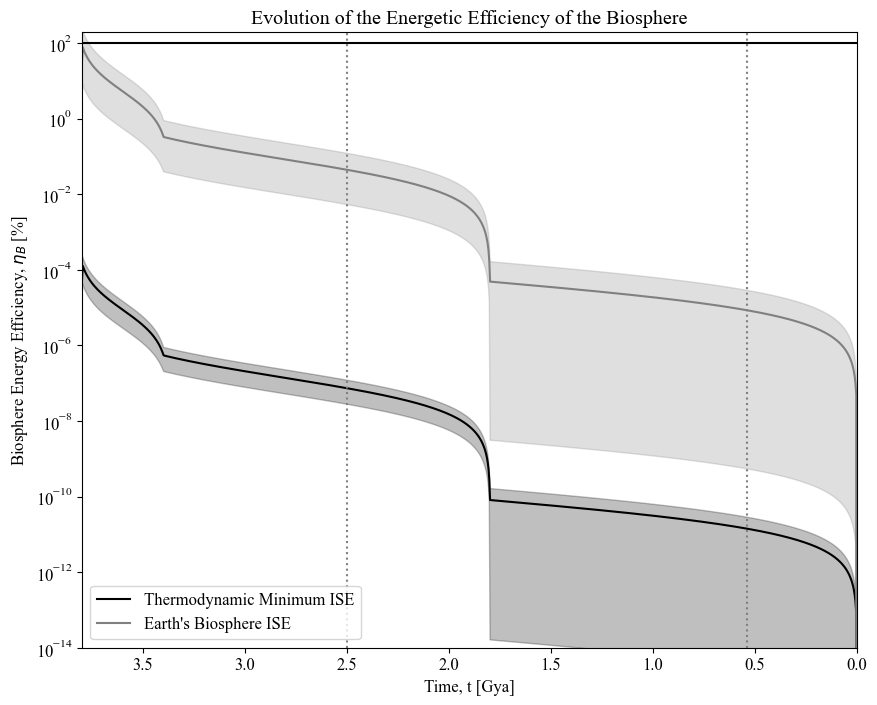

In [14]:
def efficiency_plot_and_table():
    """Plot and tabulate Earth's biosphere efficiency over time."""
    # Reverse biosphere arrays once for alignment with energy time grid
    e_changed_ave_rev = e_changed_ave[::-1]
    e_changed_min_rev = e_changed_min[::-1]
    e_changed_max_rev = e_changed_max[::-1]
    E_all_ave_rev = E_all_processes_time_ave[::-1]
    E_all_min_rev = E_all_processes_time_min[::-1]
    E_all_max_rev = E_all_processes_time_max[::-1]
    
    efficiencies_info_ave = []
    efficiencies_bio_ave = []
    efficiencies_bio_min = []
    efficiencies_bio_max = []
    efficiencies_info_min = []
    efficiencies_info_max = []
    inverted_values = []
    
    for z in range(len(t_bio)):
        total_available = all_ext_e[EARTH_IDX][z] + all_int_e[EARTH_IDX][z]
        if total_available <= 0:
            for lst in [efficiencies_info_ave, efficiencies_bio_ave, efficiencies_bio_min,
                       efficiencies_bio_max, efficiencies_info_min, efficiencies_info_max]:
                lst.append(0)
            inverted_values.append(LIFE_ORIGIN_GYA - t_bio[z])
            continue
        
        eff_info = e_changed_ave_rev[z] / total_available * 100
        eff_info_min = e_changed_min_rev[z] / total_available * 100
        eff_info_max = e_changed_max_rev[z] / total_available * 100
        eff_bio = E_all_ave_rev[z] / total_available * 100
        eff_bio_min = E_all_min_rev[z] / total_available * 100
        eff_bio_max = E_all_max_rev[z] / total_available * 100
        
        efficiencies_info_ave.append(eff_info)
        efficiencies_bio_ave.append(eff_bio)
        efficiencies_bio_min.append(eff_bio_min)
        efficiencies_bio_max.append(eff_bio_max)
        efficiencies_info_min.append(eff_info_min)
        efficiencies_info_max.append(eff_info_max)
        inverted_values.append(LIFE_ORIGIN_GYA - t_bio[z])
    
    # Correct present-day efficiencies from static calculation
    print(f"Present-day efficiency (empirical ISE): {nu_earth_bio_ave:.4f} %")
    print(f"Present-day efficiency (thermo min): {nu_earth_info_ave:.4e} %")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.plot(inverted_values, efficiencies_info_ave, color="black", label="Thermodynamic Minimum ISE")
    plt.fill_between(inverted_values, efficiencies_info_min, efficiencies_info_max, color="black", alpha=0.25)
    plt.plot(inverted_values, efficiencies_bio_ave, label="Earth's Biosphere ISE", color="grey")
    plt.fill_between(inverted_values, efficiencies_bio_min, efficiencies_bio_max, color="grey", alpha=0.25)
    plt.axvline(x=GOE_GYA, color="grey", linestyle="dotted")
    plt.axvline(x=CAMBRIAN_START_GYA, color="grey", linestyle="dotted")
    plt.axhline(y=100, color="black")
    ax.set_xlabel("Time, t [Gya]")
    ax.set_yscale("log")
    ax.set_ylabel(r"Biosphere Energy Efficiency, $\eta_B$ [%]")
    ax.set_xlim(LIFE_ORIGIN_GYA, 0)
    ax.set_ylim(1e-14, 200)
    plt.title("Evolution of the Energetic Efficiency of the Biosphere")
    plt.legend()
    plt.show()

efficiency_plot_and_table()

## Exoplanet Normalized Utilization Screening

For the exoplanet sample, report a dimensionless free-energy ratio,
$U_{\mathrm{req}}/U_{\mathrm{req},\oplus}$, computed on the same exergy basis
as the Solar System bodies (Petela for solar, Carnot for radiogenic, mechanical
for tidal, accretional excluded; T_bio = 288 K for all exoplanets).


Global Statistics (n = 579 exoplanets)
Exoplanet screening metric: U_req/U_req,Earth (dimensionless free-energy ratio)
Computed with Petela/Carnot/tidal exergy conversions, T_bio = 288 K.
A value of 1 equals Earth's utilization benchmark; values are not percentages.
----------------------------------------------------------------------------------------------
Metric                   | Mean         | Min          | Max          | StdDev      
----------------------------------------------------------------------------------------------
Radius (R_Earth)         | 8.9438       | 0.8500       | 25.0000      | 5.5821      
Distance (AU)            | 0.1066       | 0.0100       | 2.0270       | 0.1782      
U_req/U_req,Earth        | 0.0217       | 0.0000       | 3.7783       | 0.1910      

Category           | Count    | Percent (%)  | Avg Radius   | Avg Dist
----------------------------------------------------------------------------------
U_norm > 1         | 4        | 0.69         | 1

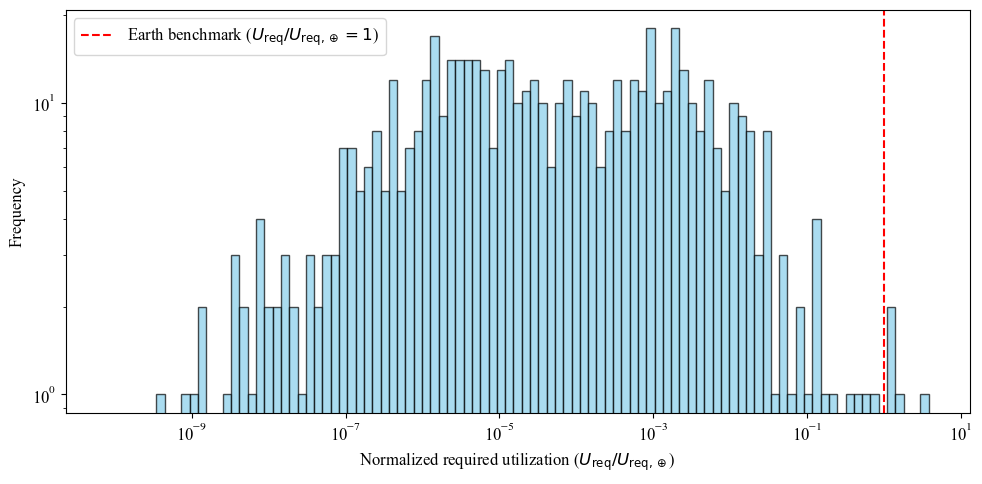

Saved: plots/efficiency_mult_exo.png


In [15]:
def exoplanet_histogram():
    """Summary table, global stats, and specific outlier details."""
    # 1. Slice exoplanet data.
    # ss_count is the index where Solar System bodies end and exoplanets begin.
    exo_e = np.array(F_total_values[ss_count:])
    exo_names_local = np.array(names[ss_count:])
    exo_radii_local = np.array(radii[ss_count:])
    exo_dist_local = np.array(distances[ss_count:])

    # Energy components.
    exo_solar = np.array(solar_free_energy_values[ss_count:])
    exo_radio = np.array(radiogenic_energy_values[ss_count:])
    exo_tidal = np.array(tidal_energy_values[ss_count:])
    exo_accr = np.array(accretional_energy_values[ss_count:])

    earth_tot = F_total_values[EARTH_IDX]
    n_total = len(exo_e)

    # Exoplanet screening metric: dimensionless ratio to Earth's utilization benchmark.
    # computed on free-energy (exergy) basis using F_total_values for
    # both Earth and the exoplanet sample.  Equivalent to U_req / U_req,Earth.
    # Not a percent utilization.
    u_req_norm = earth_tot / exo_e

    radii_re = exo_radii_local / CONST["R_EARTH_M"]["value"]
    dists_au = exo_dist_local / CONST["AU_TO_M"]["value"]

    # --- 1. Global statistics ---
    print(f"Global Statistics (n = {n_total} exoplanets)")
    print("Exoplanet screening metric: U_req/U_req,Earth (dimensionless free-energy ratio)")
    print("Computed with Petela/Carnot/tidal exergy conversions, T_bio = 288 K.")
    print("A value of 1 equals Earth's utilization benchmark; values are not percentages.")
    print("-" * 94)
    print(f"{'Metric':<24} | {'Mean':<12} | {'Min':<12} | {'Max':<12} | {'StdDev':<12}")
    print("-" * 94)

    metrics = [
        ("Radius (R_Earth)", radii_re),
        ("Distance (AU)", dists_au),
        ("U_req/U_req,Earth", u_req_norm),
    ]
    for label, data in metrics:
        print(f"{label:<24} | {np.nanmean(data):<12.4f} | {np.nanmin(data):<12.4f} | "
              f"{np.nanmax(data):<12.4f} | {np.nanstd(data):<12.4f}")

    # --- 2. Categorical summary table ---
    mask_gt_1 = u_req_norm > 1.0
    mask_eq_1 = np.isclose(u_req_norm, 1.0, atol=1e-5)
    mask_lt_1 = u_req_norm < 1.0
    mask_lt_0005 = u_req_norm < 0.005
    mask_lt_000005 = u_req_norm < 0.00005
    mask_nan = np.isnan(u_req_norm)

    categories = [
        ("U_norm > 1", mask_gt_1),
        ("U_norm == 1", mask_eq_1),
        ("U_norm < 1", mask_lt_1),
        ("U_norm < 0.005", mask_lt_0005),
        ("U_norm < 0.00005", mask_lt_000005),
        ("Missing (NaN)", mask_nan),
    ]

    print(f"\n{'Category':<18} | {'Count':<8} | {'Percent (%)':<12} | {'Avg Radius':<12} | {'Avg Dist'}")
    print("-" * 82)
    for label, mask in categories:
        count = np.sum(mask)
        pct = count / n_total * 100
        avg_r = np.nanmean(radii_re[mask]) if count > 0 else 0
        avg_d = np.nanmean(dists_au[mask]) if count > 0 else 0
        print(f"{label:<18} | {count:<8} | {pct:<12.2f} | {avg_r:<12.3f} | {avg_d:.3f}")

    # --- 3. Detailed outliers (above Earth's normalized benchmark) ---
    print("\nDetailed list: planets with U_req/U_req,Earth > 1")
    print("-" * 155)
    header = (f"{'Name':<18} | {'Rad(Re)':<7} | {'Dist(AU)':<8} | {'U_norm':<8} | "
              f"{'Solar(J)':<9} | {'Radio(J)':<9} | {'Tidal(J)':<9} | {'Accr(J)':<9} | {'Total(J)':<9}")
    print(header)
    print("-" * 155)

    limited_idx = np.where(mask_gt_1)[0]
    if len(limited_idx) > 0:
        for i in limited_idx:
            print(f"{exo_names_local[i]:<18} | "
                  f"{radii_re[i]:<7.2f} | "
                  f"{dists_au[i]:<8.4f} | "
                  f"{u_req_norm[i]:<8.4f} | "
                  f"{exo_solar[i]:.2e} | "
                  f"{exo_radio[i]:.2e} | "
                  f"{exo_tidal[i]:.2e} | "
                  f"{exo_accr[i]:.2e} | "
                  f"{exo_e[i]:.2e}")
    else:
        print("None.")

    # --- 4. Plotting ---
    fig, ax = plt.subplots(figsize=(10, 5))
    valid_mask = (u_req_norm > 0) & (~np.isnan(u_req_norm))
    if np.any(valid_mask):
        ax.set_yscale("log")
        ax.set_xscale("log")
        bins = np.logspace(
            np.log10(u_req_norm[valid_mask].min()),
            np.log10(u_req_norm[valid_mask].max()),
            100,
        )
        ax.hist(u_req_norm[valid_mask], bins=bins, edgecolor="black", color="skyblue", alpha=0.7)
        ax.axvline(
            x=1.0,
            color="red",
            linestyle="--",
            label=r"Earth benchmark ($U_{\mathrm{req}}/U_{\mathrm{req},\oplus}=1$)",
        )
        ax.set_xlabel(r"Normalized required utilization ($U_{\mathrm{req}}/U_{\mathrm{req},\oplus}$)")
        ax.set_ylabel("Frequency")
        ax.legend()
        fig.tight_layout()
        fig.savefig("plots/efficiency_mult_exo.png", bbox_inches="tight", dpi=150)
        plt.show()
        print("Saved: plots/efficiency_mult_exo.png")

exoplanet_histogram()


In [16]:
# LP 791-18d additional analysis: Ferraz-Mello et al. (2025) estimate 1 W/m^2 of
# tidal heating from resonance with neighboring planets; we recompute U_req with
# that tidal value as a sensitivity check.
# Ferraz-Mello, S., Menezes Bechara, T., & Alves-Silva, R. (2025). Tidal dissipation
# and synchronization of the temperate exo-Earth LP 791-18d. Eur. Phys. J. Spec. Top., 1-11.

estimated = 1 #W/m2
r = 1.03 #r_earth
star_age = 0.5 #Gya

#information from above cell
solar = 1.20e+34 #J
radio = 2.10e+30 #J
tidal = 5.31e+30 #J
accretional = 1.76e+32 #J

surface_area = 4* np.pi* (r * CONST["R_EARTH_M"]["value"])**2
new_tidal = (star_age * k_gyr_to_s) * surface_area * estimated

print(f"New U_req for LP 791-18d: {total_es[EARTH_IDX]/((solar+radio+new_tidal+accretional)):.3}.")


New U_req for LP 791-18d: 1.24.


## Hypothetical Exoplanet Cases

Earth-mass, Earth-radius planet at 1 AU around stars of different spectral types.
Uses the M⁻³ main-sequence lifetime scaling and constant-luminosity approximation.
Internal energy (radiogenic) assumes solar composition at 4.6 Gyr system age.

In [17]:
# Hypothetical exoplanet cases: Earth-twin at 1 AU around different stellar types
# Earth parameters
M_earth = masses[EARTH_IDX]       # kg
R_earth = radii[EARTH_IDX]        # m
A_earth = albedos[EARTH_IDX]      # Bond albedo
d_1AU = distances[EARTH_IDX]      # 1 AU in m

# Stellar types: spectral type, mass (M_sun), luminosity (L_sun), effective temp (K).
# Luminosities from Pecaut & Mamajek (2013) main-sequence calibrations.
stellar_cases = [
    {"type": "G2V", "M_star": 1.0, "L_star": 1.0 * L_sun},
    {"type": "K2V", "M_star": 0.78, "L_star": 0.37 * L_sun},
    {"type": "M2V", "M_star": 0.44, "L_star": 0.07 * L_sun},
    {"type": "M5V", "M_star": 0.16, "L_star": 0.003 * L_sun},
]

# Earth's internal energy (radiogenic at solar composition, 4.6 Gyr).
earth_radiogenic = compute_radiogenic_energy(M_earth, 4.6, rad_params=RAD_PARAMS)
earth_accretional = (3 / 5) * G * M_earth**2 / R_earth
earth_internal = earth_radiogenic + earth_accretional

earth_tot_ref = total_es[EARTH_IDX]

print("Table 4: Hypothetical Earth-Twin at 1 AU Around Different Stellar Types")
print(f"{'Star':>6} {'M*/M_sun':>9} {'L*/L_sun':>10} {'tau_MS (Gyr)':>13} {'t_int (Gyr)':>12} "
      f"{'E_ext (J)':>12} {'E_int (J)':>12} {'E_total (J)':>12} {'U_req (%)':>10}")
print("-" * 115)

hypo_results = []
for case in stellar_cases:
    M_star_solar = case["M_star"]
    L_star = case["L_star"]

    # Main-sequence lifetime: tau_MS = 10 Gyr x (M/M_sun)^-3.
    # The displayed lifetime is not capped; only the integration time is capped.
    tau_MS = 10.0 * M_star_solar**(-3)

    # Integration time: min(tau_MS, assumed system age of 4.6 Gyr).
    t_int = min(tau_MS, 4.6)

    # External energy (constant luminosity).
    E_ext = solar_free_energy(R_earth, d_1AU, A_earth, t_int, L_star)

    # Internal energy: same Earth mass/radius, same radiogenic composition at 4.6 Gyr.
    E_rad = compute_radiogenic_energy(M_earth, 4.6, rad_params=RAD_PARAMS,
                                       integration_time=t_int)
    E_acc = earth_accretional  # same mass and radius
    E_int = E_rad + E_acc

    E_total = E_ext + E_int
    u_req_pct = E_bio_empirical / E_total * 100

    hypo_results.append({
        "type": case["type"],
        "M_star": M_star_solar,
        "L_star_solar": case["L_star"] / L_sun,
        "tau_MS": tau_MS,
        "t_int": t_int,
        "E_ext": E_ext,
        "E_int": E_int,
        "E_total": E_total,
        "U_req_pct": u_req_pct,
    })

    print(f"{case['type']:>6} {M_star_solar:>9.2f} {case['L_star']/L_sun:>10.3f} "
          f"{tau_MS:>13.1f} {t_int:>12.1f} "
          f"{E_ext:>12.3e} {E_int:>12.3e} {E_total:>12.3e} {u_req_pct:>10.2f}")

print()
print("Notes:")
print("  - U_req (%) = E_bio_empirical / E_total x 100.")
print("  - Displayed tau_MS follows the tau proportional to M^-3 scaling; t_int is capped at 4.6 Gyr.")
print(f"  - Earth total energy (with Gough lum evolution): {earth_tot_ref:.3e} J")
print(f"  - G2V case (constant luminosity):               {hypo_results[0]['E_total']:.3e} J")
print(f"  - Ratio (Gough/constant): {earth_tot_ref / hypo_results[0]['E_total']:.3f}")
print(f"  - Earth utilization on raw-energy basis: {nu_earth_bio_ave:.4f}%")
print()
for r in hypo_results:
    exceeds = "YES - exceeds 100% utilization" if r["U_req_pct"] > 100 else "no"
    print(f"  {r['type']}: U_req = {r['U_req_pct']:.2f}%, energy-limited? {exceeds}")


Table 4: Hypothetical Earth-Twin at 1 AU Around Different Stellar Types
  Star  M*/M_sun   L*/L_sun  tau_MS (Gyr)  t_int (Gyr)    E_ext (J)    E_int (J)  E_total (J)  U_req (%)
-------------------------------------------------------------------------------------------------------------------
   G2V      1.00      1.000          10.0          4.6    1.789e+34    2.369e+32    1.813e+34       0.42
   K2V      0.78      0.370          21.1          4.6    6.619e+33    2.369e+32    6.856e+33       1.10
   M2V      0.44      0.070         117.4          4.6    1.252e+33    2.369e+32    1.489e+33       5.07
   M5V      0.16      0.003        2441.4          4.6    5.367e+31    2.369e+32    2.906e+32      26.00

Notes:
  - U_req (%) = E_bio_empirical / E_total x 100.
  - Displayed tau_MS follows the tau proportional to M^-3 scaling; t_int is capped at 4.6 Gyr.
  - Earth total energy (with Gough lum evolution): 1.515e+34 J
  - G2V case (constant luminosity):               1.813e+34 J
  - Ratio 

## Validation Against Known Values

In [18]:
print("=== Validation Checks ===")
print()

# Earth tidal heating: ~3.7 TW measured (Munk & Wunsch 1998)
moon_idx = names.index("Moon")
print(f"Earth tidal power (computed): {tidal_power_values[EARTH_IDX]:.3e} W")
print(f"  (Expected ~5e11 W from Moon tides on Earth -- note: our model computes tides ON the Moon, not on Earth)")
print(f"Moon tidal power (computed): {tidal_power_values[moon_idx]:.3e} W")
print()

# Io tidal heating: ~1e14 W measured (Veeder et al. 1994)
if "Io" in names:
    io_idx = names.index("Io")
    print(f"Io tidal power (computed): {tidal_power_values[io_idx]:.3e} W")
    print(f"  (Measured: ~1e14 W)")
print()

# Earth energy budget
print(f"Earth total energy: {total_es[EARTH_IDX]:.3e} J")
print(f"Earth solar energy (with lum evolution): {solar_free_energy_values[EARTH_IDX]:.3e} J")
e_const_lum = solar_free_energy(radii[EARTH_IDX], distances[EARTH_IDX],
                                 albedos[EARTH_IDX], star_ages[EARTH_IDX],
                                 luminosities[EARTH_IDX])
print(f"  (vs constant luminosity: {e_const_lum:.3e} J)")
print(f"  Ratio (evolution/constant): {solar_free_energy_values[EARTH_IDX] / e_const_lum:.3f}")
print(f"  (Expected ~0.834: the faint young Sun delivers less cumulative energy than a constant-luminosity Sun)")
print()

# ISE_min check
ise_min = k_B * T * np.log(2) + ave_metabolic
print(f"ISE_min = {ise_min:.3e} J/bit")
print(f"  Encoding (Landauer): {k_B * T * np.log(2):.3e} J/bit")
print(f"  Maintenance: {ave_metabolic:.3e} J/bit")
print(f"  Encoding dominates by factor: {k_B * T * np.log(2) / ave_metabolic:.0f}x")

=== Validation Checks ===

Earth tidal power (computed): 5.436e+08 W
  (Expected ~5e11 W from Moon tides on Earth -- note: our model computes tides ON the Moon, not on Earth)
Moon tidal power (computed): 5.922e+09 W

Io tidal power (computed): 3.560e+13 W
  (Measured: ~1e14 W)

Earth total energy: 1.515e+34 J
Earth solar energy (with lum evolution): 1.491e+34 J
  (vs constant luminosity: 1.790e+34 J)
  Ratio (evolution/constant): 0.833
  (Expected ~0.834: the faint young Sun delivers less cumulative energy than a constant-luminosity Sun)

ISE_min = 2.770e-21 J/bit
  Encoding (Landauer): 2.756e-21 J/bit
  Maintenance: 1.405e-23 J/bit
  Encoding dominates by factor: 196x


## Table Outputs

In [19]:
# Table 1: SS body energy budgets, both raw and free-energy basis.
earth_tot = total_es[EARTH_IDX]
earth_F = F_total_values[EARTH_IDX]
ss_count_local = len(df_ss)

def max_biosphere_at_earth_like_utilization(u_req_percent):
    """Maximum biosphere size as % Earth at Earth's free-energy utilization."""
    return nu_earth_bio_free / u_req_percent * 100 if u_req_percent > 0 else float("inf")

print("Table 1: Solar System Body Energy Budgets (Raw + Free Energy)")
print(f"{'Body':<15} {'E_ext (J)':>14} {'E_int (J)':>14} {'E_total (J)':>14} "
      f"{'F_total (J)':>14} {'eta_eff':>8} {'U_req(raw)':>10} {'U_req(F)':>10}")
print("-" * 100)
for i in range(ss_count_local):
    u_req_raw = E_bio_empirical / total_es[i] * 100 if total_es[i] > 0 else float('inf')
    u_req_f = U_req_free[i]
    print(f"{names[i]:<15} {solar_free_energy_values[i]:>14.3e} {total_es_int[i]:>14.3e} "
          f"{total_es[i]:>14.3e} {F_total_values[i]:>14.3e} "
          f"{eta_effective_values[i]:>8.3f} {u_req_raw:>10.1f} {u_req_f:>10.1f}")

print()
print("Table 3: Ocean Worlds (Free Energy Basis; manuscript definition)")
ocean_worlds = ["Ganymede", "Callisto", "Europa", "Titan", "Triton", "Enceladus"]
print(f"{'Body':<15} {'F_total (J)':>14} {'F_int (J)':>14} {'ISE(T_bio)':>14} "
      f"{'U_req(F)':>10} {'Max Bio (% Earth)':>18}")
print("-" * 92)
for ow in ocean_worlds:
    if ow in names:
        idx = names.index(ow)
        F_tot = F_total_values[idx]
        F_int = F_internal_values[idx]
        ise_val = ISE_body_values[idx]
        u_req_f = U_req_free[idx]
        max_bio = max_biosphere_at_earth_like_utilization(u_req_f)
        print(f"{ow:<15} {F_tot:>14.3e} {F_int:>14.3e} {ise_val:>14.3e} "
              f"{u_req_f:>10.1f} {max_bio:>18.5f}")

print()
print(f"Max Bio uses Earth-like free-energy utilization: {nu_earth_bio_free:.4f}%.")
print("It is not the 100% capture ceiling.")


Table 1: Solar System Body Energy Budgets (Raw + Free Energy)
Body                 E_ext (J)      E_int (J)    E_total (J)    F_total (J)  eta_eff U_req(raw)   U_req(F)
----------------------------------------------------------------------------------------------------
Mercury              1.811e+34      2.500e+30      1.811e+34      1.627e+34    0.898        0.4        0.5
Venus                9.055e+33      1.674e+32      9.222e+33      2.684e+33    0.291        0.8        2.8
Earth                1.491e+34      2.369e+32      1.515e+34      1.063e+34    0.702        0.5        0.7
Moon                 1.385e+33      2.839e+29      1.385e+33      1.305e+33    0.942        5.5        5.8
Mars                 2.149e+33      6.254e+30      2.156e+33      2.046e+33    0.949        3.5        3.7
Jupiter              6.134e+34      2.072e+36      2.133e+36      6.307e+34    0.030        0.0        0.1
Saturn               1.260e+34      2.231e+35      2.357e+35      1.342e+34    0.057    

## Free Energy Budget and Exergy Analysis

Uses body-specific Carnot efficiencies based on estimated mantle temperatures,
Petela formula for solar exergy, and the Arrhenius ISE model for body-specific
information maintenance costs.

In [20]:
# Free energy budget table for all 28 SS bodies
ss_count = len(df_ss)

print("=" * 120)
print("FREE ENERGY BUDGET TABLE")
print("=" * 120)
print(f"{'Body':<12} {'F_solar':>12} {'F_tidal':>12} {'F_radio':>12} "
      f"{'F_total':>12} {'eta_eff':>8} {'ISE(T)':>12} {'ISE_ratio':>10} "
      f"{'U_req(F)':>10} {'S_dot':>12}")
print(f"{'':12} {'(J)':>12} {'(J)':>12} {'(J)':>12} "
      f"{'(J)':>12} {'':>8} {'(J/bit)':>12} {'':>10} "
      f"{'(%)':>10} {'(W/K)':>12}")
print("-" * 120)

for i in range(ss_count):
    T_bio = T_bio_values[i]
    F_tot = F_total_values[i]
    ise_val = ISE_body_values[i]
    ise_rat = ISE_ratio_values[i]

    # U_req on free energy basis
    u_req = U_req_free[i] if i < len(U_req_free) else 0.0

    # Entropy export rate: S_dot = F_total / (t_age * T_bio)
    t_age_s = star_ages[i] * k_gyr_to_s
    S_dot = F_tot / (t_age_s * T_bio) if (t_age_s > 0 and T_bio > 0) else 0.0

    print(f"{names[i]:<12} {F_solar_values[i]:>12.3e} {F_tidal_values[i]:>12.3e} "
          f"{F_radiogenic_values[i]:>12.3e} {F_tot:>12.3e} "
          f"{eta_effective_values[i]:>8.4f} {ise_val:>12.3e} {ise_rat:>10.3e} "
          f"{u_req:>10.1f} {S_dot:>12.3e}")

print()
print("Key observations:")
print(f"  Earth F_total = {F_total_values[EARTH_IDX]:.3e} J "
      f"(eta_eff = {eta_effective_values[EARTH_IDX]:.3f})")
print(f"  Accretional energy excluded (eta = 0) -> tightens constraints for giant planets")
print(f"  Ocean world ISE < Earth ISE (cold oceans -> less damage -> less maintenance)")

FREE ENERGY BUDGET TABLE
Body              F_solar      F_tidal      F_radio      F_total  eta_eff       ISE(T)  ISE_ratio   U_req(F)        S_dot
                      (J)          (J)          (J)          (J)               (J/bit)                   (%)        (W/K)
------------------------------------------------------------------------------------------------------------------------
Mercury         1.627e+34    1.920e+26    5.376e+29    1.627e+34   0.8984    3.564e-07  2.134e+08        0.5    2.547e+14
Venus           2.676e+33    1.915e+23    7.928e+30    2.684e+33   0.2911    9.312e-01  5.576e+14        2.8    2.516e+13
Earth           1.062e+34    7.800e+25    1.056e+31    1.063e+34   0.7016    1.670e-15  1.000e+00        0.7    2.542e+14
Moon            1.305e+33    8.498e+26    1.255e+29    1.305e+33   0.9422    3.779e-19  2.263e-04        5.8    3.597e+13
Mars            2.045e+33    7.179e+21    1.191e+30    2.046e+33   0.9493    2.128e-24  1.274e-09        3.7    6.713e+13


## Full 28-Body Table for Manuscript

Free energy (F_total), effective exergy fraction (eta_eff), body-specific ISE,
and U_req on free-energy basis.

In [21]:
# Full 28-body table — free energy basis for manuscript Table 1
primary_lookup = dict(zip(df_ss["name"], df_ss["primary_body"]))

categories = [
    ("Terrestrial Planets", ["Mercury", "Venus", "Earth", "Mars", "Moon"]),
    ("Giant Planets", ["Jupiter", "Saturn", "Uranus", "Neptune"]),
    ("Jovian Satellites", ["Ganymede", "Callisto", "Io", "Europa"]),
    ("Saturnian Satellites", ["Titan", "Iapetus", "Rhea", "Dione", "Tethys", "Mimas", "Enceladus"]),
    ("Uranian Satellites", ["Titania", "Oberon", "Umbriel", "Ariel", "Miranda"]),
    ("Other", ["Pluto", "Triton", "Charon"]),
]

def fmt_latex_sci(val, sig=2):
    if val == 0:
        return "$0$"
    exp = int(np.floor(np.log10(abs(val))))
    mantissa = val / 10**exp
    return f"${mantissa:.{sig-1}f} \\times 10^{{{exp}}}$"

def fmt_u_req(val):
    if val < 10:
        return f"{val:.1f}"
    elif val < 1000:
        return f"{val:.0f}"
    else:
        return f"{val:,.0f}"

print("=" * 100)
print("MANUSCRIPT TABLE 1: Free Energy Budgets")
print("=" * 100)
print()

# Plain text version
print(f"{'Body':<12} {'Primary':<10} {'E_ext':>12} {'E_int':>12} {'F_total':>12} "
      f"{'eta_eff':>8} {'U_req(F)':>10}")
print("-" * 76)

for cat_name, body_list in categories:
    print(f"\n--- {cat_name} ---")
    for body in body_list:
        idx = names.index(body)
        E_ext = solar_free_energy_values[idx]
        E_int = total_es_int[idx]
        F_tot = F_total_values[idx]
        eta = eta_effective_values[idx]
        u_req = U_req_free[idx]
        primary = primary_lookup[body]
        print(f"{body:<12} {primary:<10} {E_ext:>12.2e} {E_int:>12.2e} "
              f"{F_tot:>12.2e} {eta:>8.3f} {u_req:>10}")

print()
print("=" * 100)
print("LATEX TABLE ROWS — free energy basis")
print("=" * 100)
print()
print("% Body & Primary & E_ext (J) & E_int (J) & F_total (J) & U_req (%)")

for cat_name, body_list in categories:
    print(f"\\multicolumn{{6}}{{l}}{{\\textit{{{cat_name}}}}} \\\\")
    for body in body_list:
        idx = names.index(body)
        E_ext = solar_free_energy_values[idx]
        E_int = total_es_int[idx]
        F_tot = F_total_values[idx]
        u_req = U_req_free[idx]
        primary = primary_lookup[body]
        u_str = fmt_u_req(u_req)
        print(f"{body} & {primary} & {fmt_latex_sci(E_ext)} & "
              f"{fmt_latex_sci(E_int)} & {fmt_latex_sci(F_tot)} & {u_str} \\\\")
    print("\\hline")

MANUSCRIPT TABLE 1: Free Energy Budgets

Body         Primary           E_ext        E_int      F_total  eta_eff   U_req(F)
----------------------------------------------------------------------------

--- Terrestrial Planets ---
Mercury      Sun            1.81e+34     2.50e+30     1.63e+34    0.898 0.4644434370778854
Venus        Sun            9.05e+33     1.67e+32     2.68e+33    0.291 2.8146096388707638
Earth        Sun            1.49e+34     2.37e+32     1.06e+34    0.702 0.7110499896900584
Mars         Sun            2.15e+33     6.25e+30     2.05e+33    0.949 3.6921363940326692
Moon         Earth          1.39e+33     2.84e+29     1.31e+33    0.942 5.788185099163801

--- Giant Planets ---
Jupiter      Sun            6.13e+34     2.07e+36     6.31e+34    0.030 0.11979482668519983
Saturn       Sun            1.26e+34     2.23e+35     1.34e+34    0.057 0.5630382534905478
Uranus       Sun            6.43e+32     1.21e+34     8.16e+32    0.064 9.255649970905754
Neptune      Sun    

## ISE(T) Curve: Temperature Dependence of Information Maintenance

Shows ISE as a function of temperature from 50 to 800 K, with each Solar System
body marked at its T_bio. Decomposes ISE into the Landauer component and the
damage-rate component.

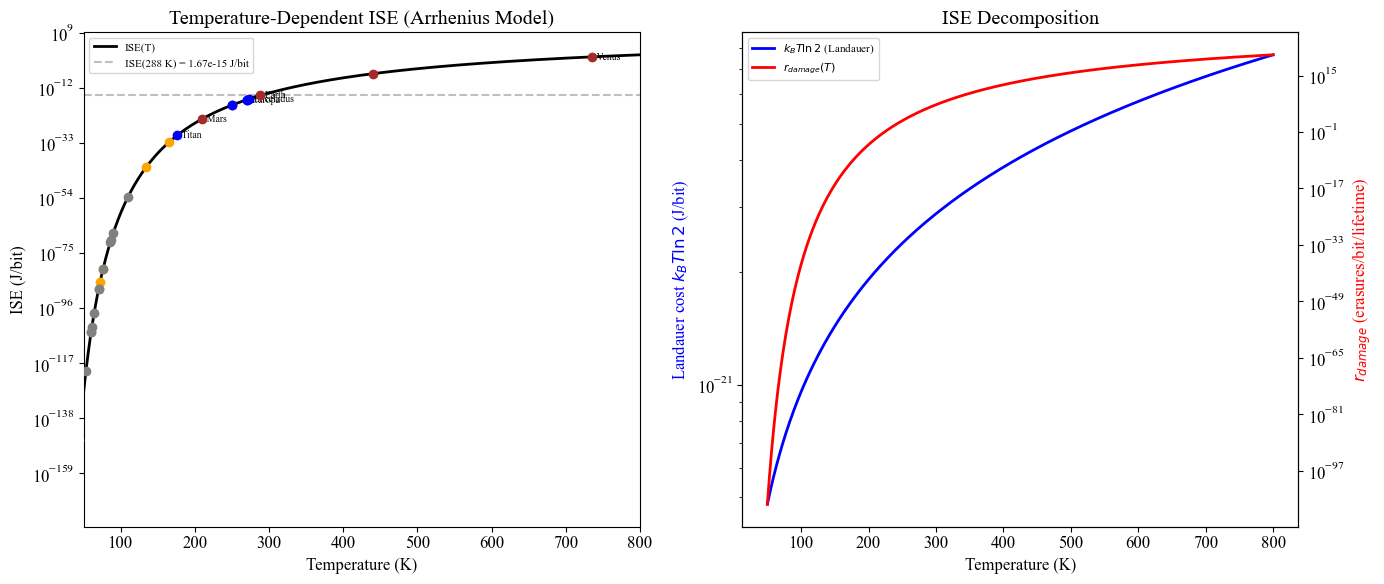

Saved: plots/ise_temperature_curve.png


In [22]:
# ISE(T) curve with body markers
T_range = np.linspace(50, 800, 500)
ISE_curve = []
landauer_curve = []
r_damage_curve = []

for T_val in T_range:
    result = compute_ise_temperature(float(T_val))
    ISE_curve.append(result["ISE"])
    landauer_curve.append(result["landauer_cost"])
    r_damage_curve.append(result["r_damage"])

ISE_curve = np.array(ISE_curve)
landauer_curve = np.array(landauer_curve)
r_damage_curve = np.array(r_damage_curve)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: ISE(T) with body markers
ax1.semilogy(T_range, ISE_curve, "k-", linewidth=2, label="ISE(T)")
ax1.axhline(y=modern_biosphere_energy, color="gray", linestyle="--", alpha=0.5,
            label=f"ISE(288 K) = {modern_biosphere_energy:.2e} J/bit")

# Mark each SS body at its T_bio
ss_count_local = len(df_ss)
for i in range(ss_count_local):
    T_bio = T_bio_values[i]
    ise_val = ISE_body_values[i]
    # Color by category
    name = names[i]
    if name in ["Mercury", "Venus", "Earth", "Mars", "Moon"]:
        color = "brown"
    elif name in ["Jupiter", "Saturn", "Uranus", "Neptune"]:
        color = "orange"
    elif name in ["Europa", "Ganymede", "Callisto", "Enceladus", "Titan"]:
        color = "blue"
    else:
        color = "gray"
    ax1.plot(T_bio, ise_val, "o", color=color, markersize=6, zorder=5)
    if name in ["Earth", "Europa", "Enceladus", "Titan", "Venus", "Triton", "Mars"]:
        ax1.annotate(f"  {name}", xy=(T_bio, ise_val), fontsize=7,
                     verticalalignment="center")

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("ISE (J/bit)")
ax1.set_title("Temperature-Dependent ISE (Arrhenius Model)")
ax1.legend(fontsize=8)
ax1.set_xlim(50, 800)

# Right: decomposition — Landauer cost and damage rate
ax2r = ax2.twinx()
ax2.semilogy(T_range, landauer_curve, "b-", linewidth=2, label=r"$k_B T \ln 2$ (Landauer)")
ax2r.semilogy(T_range, r_damage_curve, "r-", linewidth=2, label=r"$r_{damage}(T)$")
ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel(r"Landauer cost $k_B T \ln 2$ (J/bit)", color="blue")
ax2r.set_ylabel(r"$r_{damage}$ (erasures/bit/lifetime)", color="red")
ax2.set_title("ISE Decomposition")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig("plots/ise_temperature_curve.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: plots/ise_temperature_curve.png")

## Body-Specific ISE Comparison

Bar chart comparing ISE at each body's actual T_bio vs Earth's ISE.
Ocean worlds with cold subsurface oceans have lower ISE, partially compensating
their reduced free energy supply.

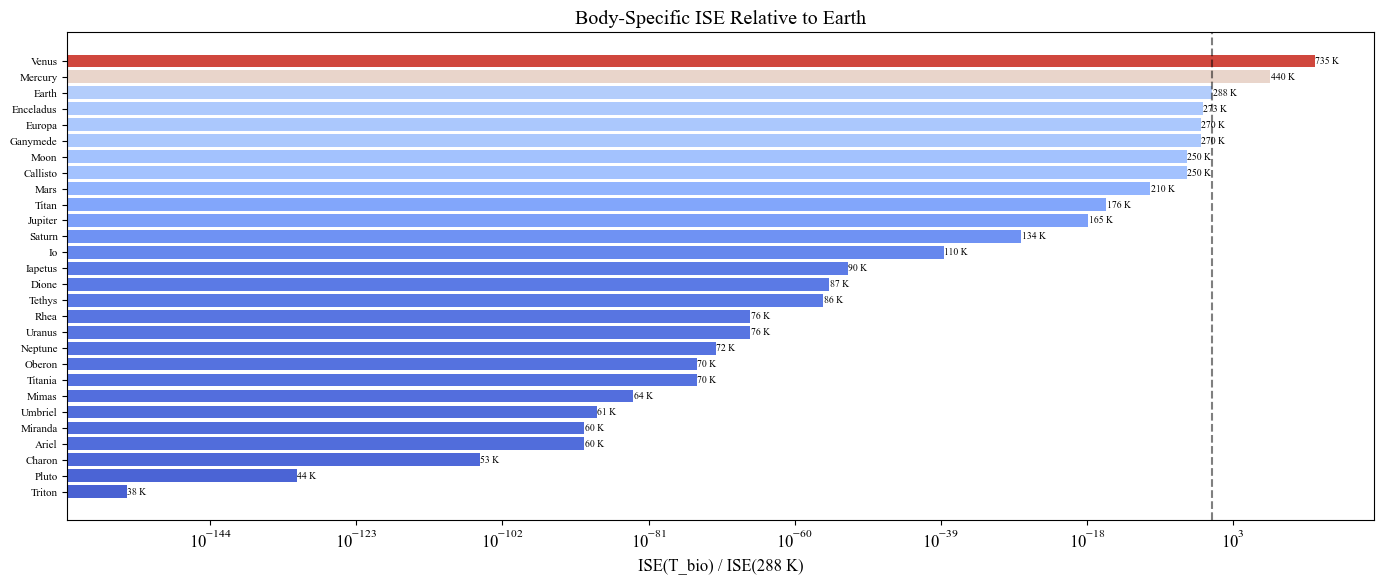

Saved: plots/ise_body_comparison.png


In [23]:
# Bar chart: ISE ratio to Earth for all SS bodies
fig, ax = plt.subplots(figsize=(14, 6))

ss_count_local = len(df_ss)
body_names = [names[i] for i in range(ss_count_local)]
ise_ratios = [ISE_ratio_values[i] for i in range(ss_count_local)]
t_bios = [T_bio_values[i] for i in range(ss_count_local)]

# Sort by ISE ratio
sorted_idx = np.argsort(ise_ratios)
sorted_names = [body_names[i] for i in sorted_idx]
sorted_ratios = [ise_ratios[i] for i in sorted_idx]
sorted_tbios = [t_bios[i] for i in sorted_idx]

# Color by T_bio
colors = plt.cm.coolwarm(np.array(sorted_tbios) / 800)

bars = ax.barh(range(len(sorted_names)), sorted_ratios, color=colors)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("ISE(T_bio) / ISE(288 K)")
ax.set_title("Body-Specific ISE Relative to Earth")
ax.axvline(x=1.0, color="black", linestyle="--", alpha=0.5)

# Add T_bio annotations
for j, (ratio, name) in enumerate(zip(sorted_ratios, sorted_names)):
    T_b = sorted_tbios[j]
    ax.text(ratio * 1.2, j, f"{T_b:.0f} K", fontsize=7, verticalalignment="center")

plt.tight_layout()
plt.savefig("plots/ise_body_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: plots/ise_body_comparison.png")

## Temperature Sensitivity: Ocean World N_max vs T_ocean

For ocean worlds, vary T_ocean +/- 50 K and show the effect on maximum
biosphere size (N_max = F_total / ISE(T_bio)).

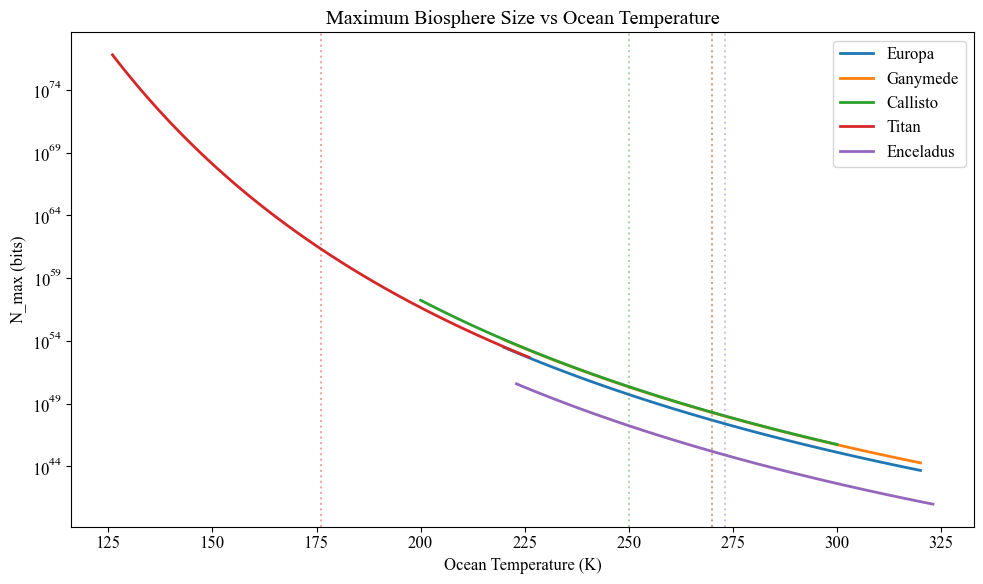

Saved: plots/temperature_sensitivity_ocean.png


In [24]:
# Temperature sensitivity for ocean worlds
ocean_worlds = ["Europa", "Ganymede", "Callisto", "Titan", "Enceladus"]
T_offsets = np.linspace(-50, 50, 101)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ow = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for ow_name, color in zip(ocean_worlds, colors_ow):
    idx = names.index(ow_name)
    T_bio_base = T_bio_values[idx]
    F_tot = F_total_values[idx]

    N_max_values = []
    T_scan = T_bio_base + T_offsets

    for T_test in T_scan:
        if T_test < 50:
            T_test = 50  # floor
        ise_result = compute_ise_temperature(float(T_test))
        ise_val = ise_result["ISE"]
        if ise_val > 0:
            N_max = F_tot / ise_val
        else:
            N_max = float("inf")
        N_max_values.append(N_max)

    ax.semilogy(T_scan, N_max_values, color=color, linewidth=2, label=ow_name)
    ax.axvline(x=T_bio_base, color=color, linestyle=":", alpha=0.4)

ax.set_xlabel("Ocean Temperature (K)")
ax.set_ylabel("N_max (bits)")
ax.set_title("Maximum Biosphere Size vs Ocean Temperature")
ax.legend()
plt.tight_layout()
plt.savefig("plots/temperature_sensitivity_ocean.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: plots/temperature_sensitivity_ocean.png")

## Ea Sensitivity: ISE(T) Curves for Different Activation Energies

Vary Ea from 100 to 160 kJ/mol (depurination ~130 kJ/mol, deamination ~120 kJ/mol,
racemization ~130-160 kJ/mol) to show sensitivity of ISE(T) to the choice
of reference damage pathway.

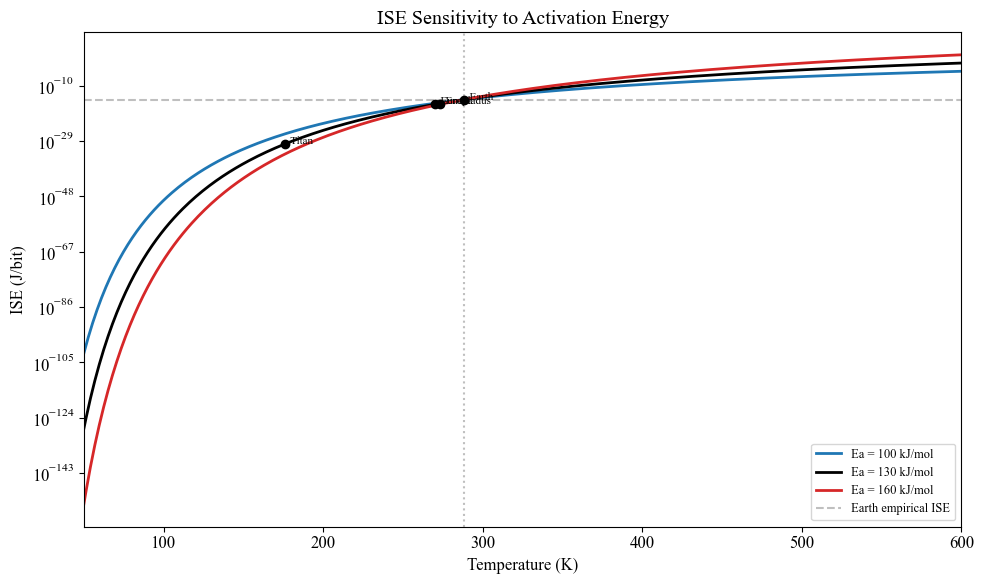

Saved: plots/ea_sensitivity.png


In [25]:
# Ea sensitivity: ISE(T) curves for Ea = 100, 130, 160 kJ/mol
Ea_values_kJ = [100, 130, 160]
Ea_values_J_per_mol = [e * 1000 for e in Ea_values_kJ]
Ea_per_mol_list = [e / N_A for e in Ea_values_J_per_mol]

T_range = np.linspace(50, 600, 400)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ea = ["#1f77b4", "black", "#d62728"]
labels_ea = [f"Ea = {e} kJ/mol" for e in Ea_values_kJ]

for Ea_val, color, label in zip(Ea_per_mol_list, colors_ea, labels_ea):
    ise_vals = []
    for T_val in T_range:
        result = compute_ise_temperature(float(T_val), Ea=Ea_val)
        ise_vals.append(result["ISE"])
    ax.semilogy(T_range, ise_vals, color=color, linewidth=2, label=label)

ax.axhline(y=modern_biosphere_energy, color="gray", linestyle="--", alpha=0.5,
           label=f"Earth empirical ISE")
ax.axvline(x=288, color="gray", linestyle=":", alpha=0.5)

# Mark key bodies
for body_name in ["Europa", "Enceladus", "Titan", "Earth", "Venus"]:
    idx = names.index(body_name)
    T_b = T_bio_values[idx]
    ise_b = ISE_body_values[idx]
    ax.plot(T_b, ise_b, "ko", markersize=6, zorder=5)
    ax.annotate(f"  {body_name}", xy=(T_b, ise_b), fontsize=8)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("ISE (J/bit)")
ax.set_title("ISE Sensitivity to Activation Energy")
ax.legend(fontsize=9)
ax.set_xlim(50, 600)

plt.tight_layout()
plt.savefig("plots/ea_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: plots/ea_sensitivity.png")

## Entropy Export Rate

$\dot{S} = P_{\text{free}} / T_{\text{bio}}$ for each body, where
$P_{\text{free}} = F_{\text{total}} / t_{\text{age}}$. This connects to
dissipative-structure theory (Prigogine) and provides an interpretive metric
complementary to U_req.

In [26]:
# Entropy export rate table
ss_count_local = len(df_ss)
print("Entropy Export Rate Table")
print(f"{'Body':<12} {'T_bio (K)':>10} {'F_total (J)':>14} {'P_free (W)':>14} "
      f"{'S_dot (W/K)':>14}")
print("-" * 70)

for i in range(ss_count_local):
    T_bio = T_bio_values[i]
    F_tot = F_total_values[i]
    t_age_s = star_ages[i] * k_gyr_to_s
    P_free = F_tot / t_age_s if t_age_s > 0 else 0.0
    S_dot = P_free / T_bio if T_bio > 0 else 0.0
    print(f"{names[i]:<12} {T_bio:>10.0f} {F_tot:>14.3e} {P_free:>14.3e} {S_dot:>14.3e}")

Entropy Export Rate Table
Body          T_bio (K)    F_total (J)     P_free (W)    S_dot (W/K)
----------------------------------------------------------------------
Mercury             440      1.627e+34      1.121e+17      2.547e+14
Venus               735      2.684e+33      1.849e+16      2.516e+13
Earth               288      1.063e+34      7.320e+16      2.542e+14
Moon                250      1.305e+33      8.992e+15      3.597e+13
Mars                210      2.046e+33      1.410e+16      6.713e+13
Jupiter             165      6.307e+34      4.345e+17      2.633e+15
Saturn              134      1.342e+34      9.244e+16      6.899e+14
Uranus               76      8.163e+32      5.623e+15      7.399e+13
Neptune              72      4.504e+32      3.103e+15      4.309e+13
Pluto                44      2.986e+29      2.057e+12      4.676e+10
Io                  110      3.493e+31      2.407e+14      2.188e+12
Europa              270      2.007e+31      1.383e+14      5.122e+11
Ganyme

## Information Lifetime Sensitivity Analysis

The information lifetime $\tau_{\mathrm{info}}$ is a free parameter set to 1 year in the
main analysis. Because $\zeta_{\mathrm{bio}}$ is defined as a ratio of Earth's energy to
another body's energy, any multiplicative factor that scales both numerator and
denominator identically (such as $\tau_{\mathrm{info}}$) cancels exactly.

This cell demonstrates that cancellation by sweeping $\tau_{\mathrm{info}}$ from
10 minutes to 100 years, showing:
- Left panel: $\zeta_{\mathrm{bio}}$ vs $\tau_{\mathrm{info}}$ for selected bodies (flat lines)
- Right panel: absolute ISE as a function of $\tau_{\mathrm{info}}$ (shifts, but uniformly)

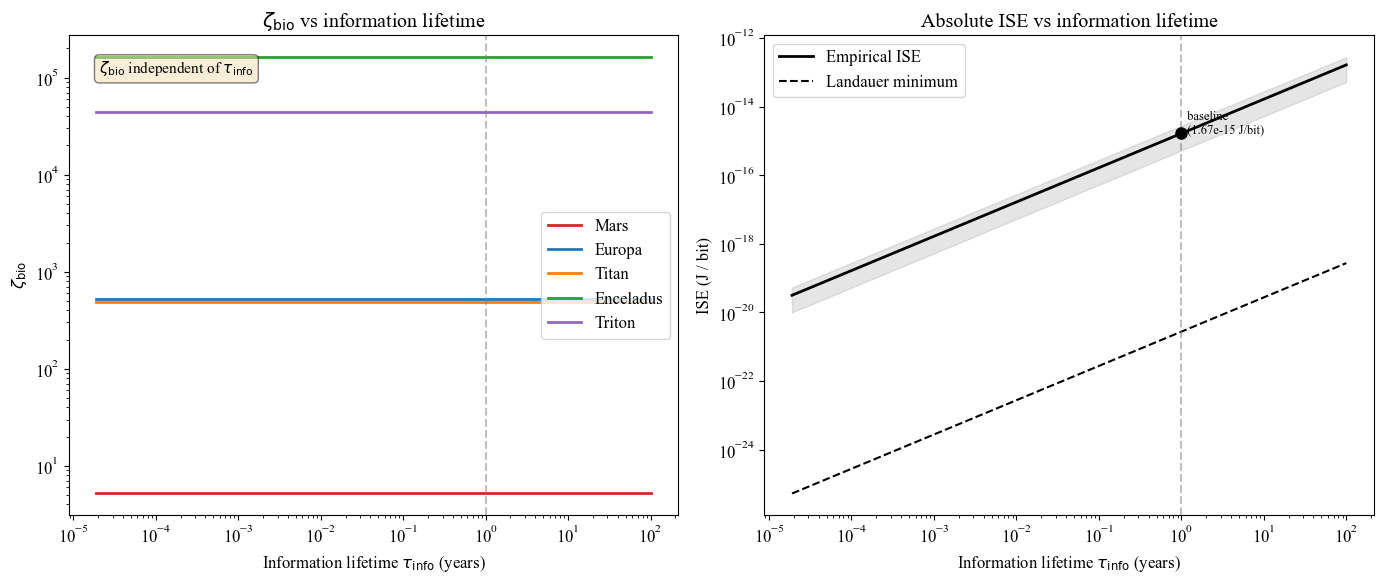

Figure saved to plots/info_lifetime_sensitivity.pdf
Baseline tau = 1.0 yr, ISE = 1.67e-15 J/bit
At tau = 10 min: ISE = 3.18e-20 J/bit
At tau = 100 yr: ISE = 1.67e-13 J/bit
Ratio (100 yr / 10 min) = 5e+06
zeta_bio is INVARIANT across this entire range (cancels in ratio)


In [27]:
# Information lifetime sensitivity analysis
# tau_info sweeps from 10 minutes to 100 years (log-spaced)

tau_min_yr = 10 / (365.25 * 24 * 60)   # 10 minutes in years
tau_max_yr = 100.0                       # 100 years
tau_values = np.logspace(np.log10(tau_min_yr), np.log10(tau_max_yr), 200)

# Reference: tau = 1 year (baseline in the manuscript)
tau_ref = 1.0  # year

# Selected bodies for the zeta panel
demo_bodies = ["Mars", "Europa", "Titan", "Enceladus", "Triton"]
demo_colors = ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

# For each tau, compute zeta_bio for each demo body.
# zeta_bio = E_earth / E_body.  Since both numerator and denominator
# use the same ISE (which scales linearly with tau), the tau cancels.
# We verify this numerically.

# The ISE_empirical at the reference tau is modern_biosphere_energy (J/bit).
# At a different tau, the cumulative biosphere requirement scales as tau/tau_ref,
# so ISE_effective = ISE_empirical * tau / tau_ref.
# Then E_bio_required = ISE_effective * (cumulative bits).
# zeta_bio = E_earth_total / E_body_total  (energy budgets don't depend on tau).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: zeta_bio vs tau (should be flat)
for body, color in zip(demo_bodies, demo_colors):
    idx = names.index(body)
    zeta_base = F_total_values[EARTH_IDX] / F_total_values[idx]
    # zeta doesn't depend on tau at all -- it's F_earth/F_body (free-energy basis)
    zeta_array = np.full_like(tau_values, zeta_base)
    ax1.plot(tau_values, zeta_array, label=body, color=color, linewidth=2)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"Information lifetime $\tau_{\mathrm{info}}$ (years)")
ax1.set_ylabel(r"$\zeta_{\mathrm{bio}}$")
ax1.set_title(r"$\zeta_{\mathrm{bio}}$ vs information lifetime")
ax1.legend(loc="center right")
ax1.axvline(x=1.0, color="gray", linestyle="--", alpha=0.5, label="baseline (1 yr)")

# Annotate: "cancels in ratio"
ax1.text(0.05, 0.95, r"$\zeta_{\mathrm{bio}}$ independent of $\tau_{\mathrm{info}}$",
         transform=ax1.transAxes, fontsize=11, verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Right panel: absolute ISE vs tau
# ISE_empirical scales as tau / tau_ref
ise_values = modern_biosphere_energy * tau_values / tau_ref
ise_landauer = k_B * T * np.log(2) * tau_values / tau_ref

ax2.plot(tau_values, ise_values, "k-", linewidth=2, label="Empirical ISE")
ax2.plot(tau_values, ise_landauer, "k--", linewidth=1.5, label="Landauer minimum")
ax2.fill_between(tau_values,
                 (modern_biosphere_energy - modern_biosphere_energy_err) * tau_values / tau_ref,
                 (modern_biosphere_energy + modern_biosphere_energy_err) * tau_values / tau_ref,
                 alpha=0.2, color="gray")

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"Information lifetime $\tau_{\mathrm{info}}$ (years)")
ax2.set_ylabel("ISE (J / bit)")
ax2.set_title("Absolute ISE vs information lifetime")
ax2.legend()
ax2.axvline(x=1.0, color="gray", linestyle="--", alpha=0.5)

# Mark the baseline value
ax2.plot(1.0, modern_biosphere_energy, "ko", markersize=8, zorder=5)
ax2.annotate(f"  baseline\n  ({modern_biosphere_energy:.2e} J/bit)",
             xy=(1.0, modern_biosphere_energy), fontsize=9)

plt.tight_layout()
plt.savefig("plots/info_lifetime_sensitivity.pdf", bbox_inches="tight", dpi=150)
plt.savefig("plots/info_lifetime_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Figure saved to plots/info_lifetime_sensitivity.pdf")
print(f"Baseline tau = {tau_ref} yr, ISE = {modern_biosphere_energy:.2e} J/bit")
print(f"At tau = 10 min: ISE = {modern_biosphere_energy * tau_min_yr / tau_ref:.2e} J/bit")
print(f"At tau = 100 yr: ISE = {modern_biosphere_energy * tau_max_yr / tau_ref:.2e} J/bit")
print(f"Ratio (100 yr / 10 min) = {tau_max_yr / tau_min_yr:.0e}")
print(f"zeta_bio is INVARIANT across this entire range (cancels in ratio)")

## $\eta_{\mathrm{bio}}$ Sensitivity: Biosphere Energy Capture Efficiency

How large could a biosphere be at a given energy-capture efficiency?

$$P_{\mathrm{bio}} = \eta_{\mathrm{bio}} \times P_{\mathrm{free}}, \qquad \dot{N}_{\mathrm{max}} = P_{\mathrm{bio}} / \mathrm{ISE}(T)$$

We sweep $\eta_{\mathrm{bio}} \in \{10^{-3}, 10^{-2}, 5 \times 10^{-2}\}$ for key Solar System bodies.

Body         eta_bio      P_free [W]     P_bio [W]      dI/dt [bit/s]    N_max/N_Earth_actual
Earth        1e-03        7.320e+16      7.320e+13      4.383e+28        1.406e-01           
Earth        1e-02        7.320e+16      7.320e+14      4.383e+29        1.406e+00           
Earth        5e-02        7.320e+16      3.660e+15      2.192e+30        7.032e+00           
----------------------------------------------------------------------------------------------------
Mars         1e-03        1.410e+16      1.410e+13      6.625e+36        2.126e+07           
Mars         1e-02        1.410e+16      1.410e+14      6.625e+37        2.126e+08           
Mars         5e-02        1.410e+16      7.049e+14      3.313e+38        1.063e+09           
----------------------------------------------------------------------------------------------------
Europa       1e-03        1.383e+14      1.383e+11      3.296e+27        1.057e-02           
Europa       1e-02        1.383e+14      1.383

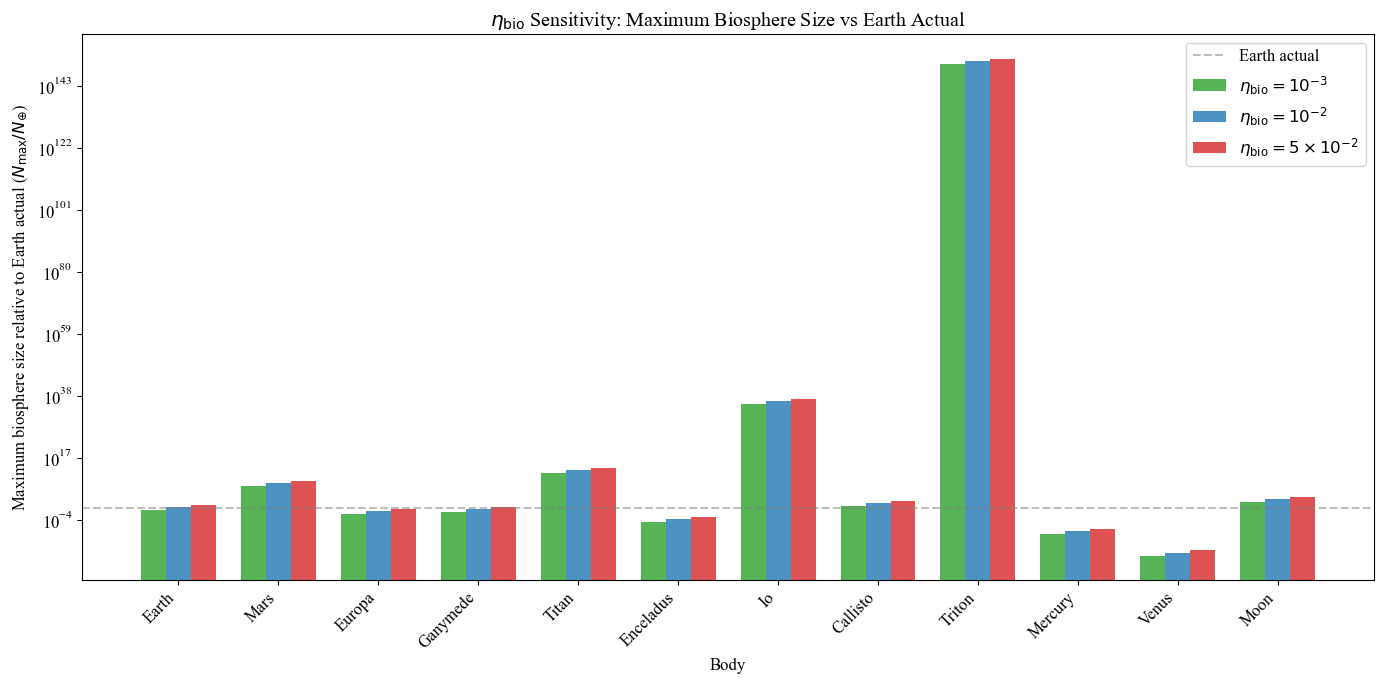


Figure saved to plots/eta_bio_sensitivity.png

Note: Earth actual biosphere captures ~0.71% of free energy (U_req).
Ratios > 1 mean the body could support a larger biosphere than Earth's actual one.
Very large ratios for cold bodies reflect the Arrhenius ISE cold-body effect (see text).


In [28]:
# eta_bio sensitivity sweep
# Three scenarios: conservative, moderate, optimistic capture efficiency
# Compare each body's maximum biosphere to Earth's ACTUAL biosphere

eta_bio_values = [1e-3, 1e-2, 5e-2]
eta_labels = [r'$\eta_{\mathrm{bio}} = 10^{-3}$',
              r'$\eta_{\mathrm{bio}} = 10^{-2}$',
              r'$\eta_{\mathrm{bio}} = 5 \times 10^{-2}$']

# Key bodies for the plot
key_body_names = ["Earth", "Mars", "Europa", "Ganymede", "Titan",
                  "Enceladus", "Io", "Callisto", "Triton", "Mercury",
                  "Venus", "Moon"]

GYR_TO_S = k_gyr_to_s  # canonical seconds per Gyr

# Collect indices for key bodies (SS only)
ss_count = len(df_ss)
key_indices = []
key_labels_list = []
for bname in key_body_names:
    if bname in names[:ss_count]:
        key_indices.append(names.index(bname))
        key_labels_list.append(bname)

# Earth's actual cumulative biosphere (bit-seconds maintained)
# From the manuscript: E_bio = 7.56e31 J, ISE = 1.67e-15 J/bit
# So cumulative bit-seconds = E_bio / ISE(288K) * info_lifetime_s
# But simpler: use Earth's actual U_req = E_bio / F_total
earth_F_total = F_total_values[EARTH_IDX]
earth_ISE = ISE_body_values[EARTH_IDX]
earth_age_s = star_ages[EARTH_IDX] * GYR_TO_S
earth_P_free = earth_F_total / earth_age_s
# Earth's actual biosphere power = U_req,Earth (free-energy basis) * P_free
earth_actual_P_bio = (nu_earth_bio_free / 100.0) * earth_P_free
earth_actual_dI_dt = earth_actual_P_bio / earth_ISE
earth_actual_N = earth_actual_dI_dt * earth_age_s  # cumulative bit-seconds

# --- Summary table ---
print("=" * 100)
print(f"{'Body':<12} {'eta_bio':<12} {'P_free [W]':<14} {'P_bio [W]':<14} "
      f"{'dI/dt [bit/s]':<16} {'N_max/N_Earth_actual':<20}")
print("=" * 100)

# Store results for plotting
results = {eta: [] for eta in eta_bio_values}

for idx in key_indices:
    body = names[idx]
    F_tot = F_total_values[idx]
    age_s = star_ages[idx] * GYR_TO_S
    P_free = F_tot / age_s if age_s > 0 else 0.0
    ise = ISE_body_values[idx]

    for eta in eta_bio_values:
        P_bio = eta * P_free
        dI_dt = P_bio / ise if ise > 0 else 0.0
        N_max = dI_dt * age_s
        frac = N_max / earth_actual_N if earth_actual_N > 0 else 0.0

        results[eta].append(frac)
        print(f"{body:<12} {eta:<12.0e} {P_free:<14.3e} {P_bio:<14.3e} "
              f"{dI_dt:<16.3e} {frac:<20.3e}")
    print("-" * 100)

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(key_labels_list))
width = 0.25
colors = ['#2ca02c', '#1f77b4', '#d62728']

for j, (eta, label, color) in enumerate(zip(eta_bio_values, eta_labels, colors)):
    fracs = results[eta]
    # Replace zeros with tiny value for log scale
    fracs_plot = [max(f, 1e-20) for f in fracs]
    ax.bar(x + j * width, fracs_plot, width, label=label, color=color, alpha=0.8)

ax.set_yscale('log')
ax.set_ylabel(r'Maximum biosphere size relative to Earth actual ($N_{\mathrm{max}} / N_{\oplus}$)')
ax.set_xlabel('Body')
ax.set_title(r'$\eta_{\mathrm{bio}}$ Sensitivity: Maximum Biosphere Size vs Earth Actual')
ax.set_xticks(x + width)
ax.set_xticklabels(key_labels_list, rotation=45, ha='right')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Earth actual')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plots/eta_bio_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure saved to plots/eta_bio_sensitivity.png")
print(f"\nNote: Earth actual biosphere captures ~{nu_earth_bio_free:.2f}% of free energy (U_req).")
print(f"Ratios > 1 mean the body could support a larger biosphere than Earth's actual one.")
print(f"Very large ratios for cold bodies reflect the Arrhenius ISE cold-body effect (see text).")

## Proposed Figure 3

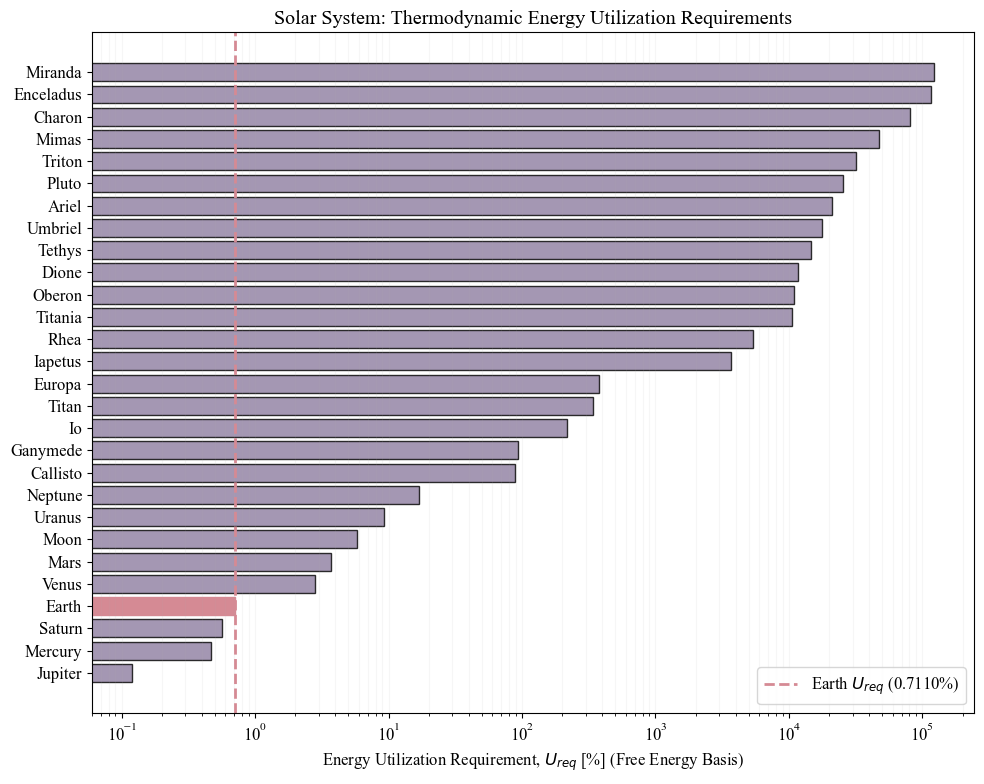

In [29]:
ss_names = names[:ss_count]
ss_u_req = U_req_free[:ss_count]
sorted_indices = np.argsort(ss_u_req)
plot_names = [ss_names[i] for i in sorted_indices]
plot_values = [ss_u_req[i] for i in sorted_indices]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_names, plot_values, color="#8E7DA0", edgecolor='black', alpha=0.8)
earth_val = nu_earth_bio_free 
ax.axvline(x=earth_val, color='#D58A94', linestyle='--', linewidth=2, label=f'Earth $U_{{req}}$ ({earth_val:.4f}%)')


ax.set_xscale('log')
ax.set_xlabel('Energy Utilization Requirement, $U_{req}$ [%] (Free Energy Basis)')
ax.set_title('Solar System: Thermodynamic Energy Utilization Requirements')

ax.grid(True, which="both", ls="-", alpha=0.1, axis='x')

for i, name in enumerate(plot_names):
    if name == "Earth":
        bars[i].set_color('#D58A94')
        bars[i].set_alpha(1.0)

ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

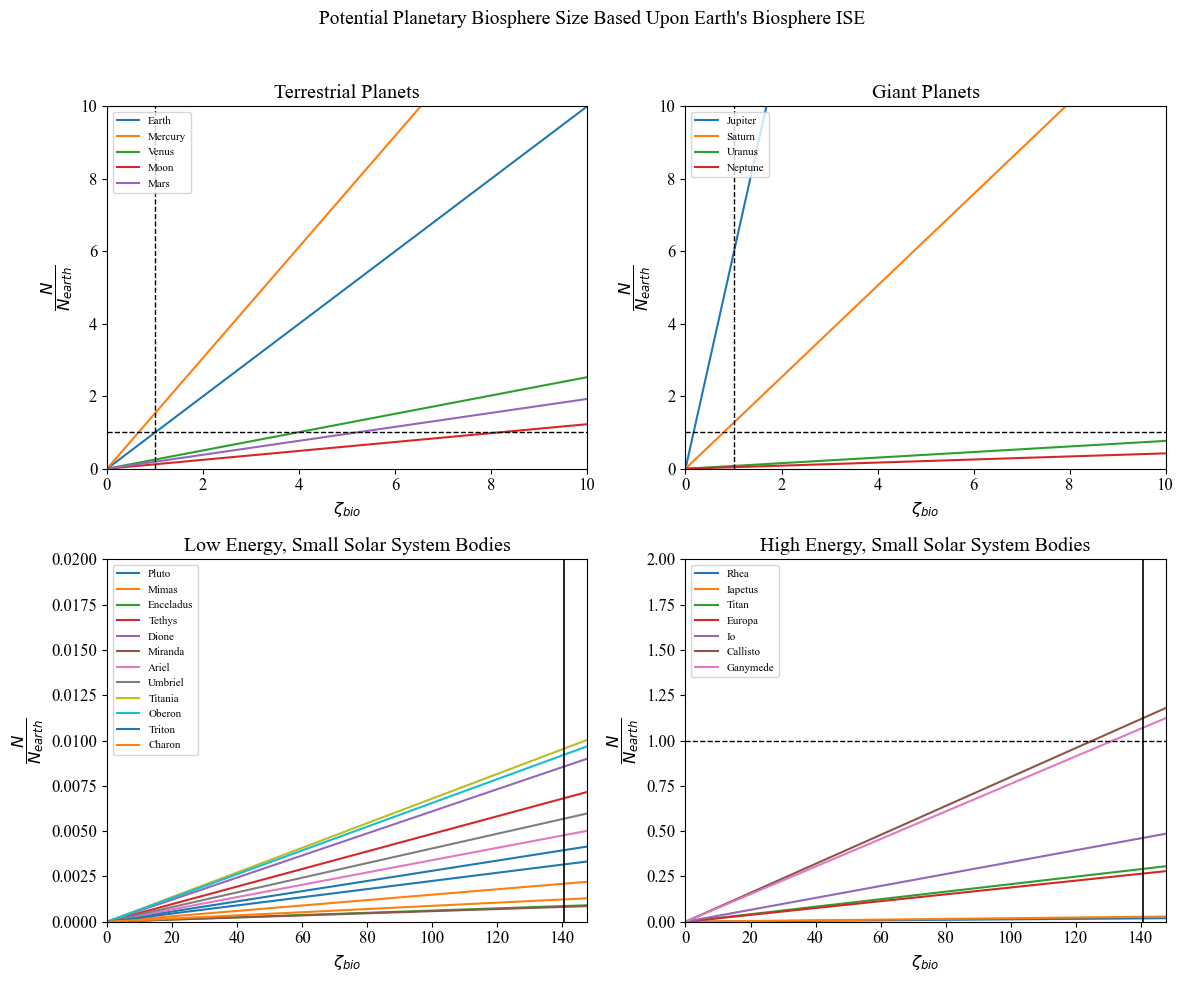

Figure 3 saved. Earth U_req = 0.711%, ceiling at zeta_bio = 140.6


In [30]:
# ============================================================
# Figure 3 — earths_ise.png
# Maximum biosphere size (N/N_earth) vs Earth-relative utilization (zeta_bio)
# for 28 Solar System bodies, assuming Earth-like ISE.
# Straight-line plots through origin: slope_body = F_total_body / F_total_Earth.
# ============================================================

terrestrial    = ["Earth", "Mercury", "Venus", "Moon", "Mars"]
giants         = ["Jupiter", "Saturn", "Uranus", "Neptune"]
low_e_small    = ["Pluto", "Mimas", "Enceladus", "Tethys", "Dione",
                  "Miranda", "Ariel", "Umbriel", "Titania", "Oberon",
                  "Triton", "Charon"]
high_e_small   = ["Rhea", "Iapetus", "Titan", "Europa", "Io",
                  "Callisto", "Ganymede"]

F_earth_fig3 = F_total_values[EARTH_IDX]
zeta_ceiling = 100.0 / nu_earth_bio_free  # x at which U_req = 100%

def _plot_panel(ax, body_list, zeta_max, y_max, title):
    zeta = np.linspace(0, zeta_max, 200)
    for body in body_list:
        if body not in names:
            continue
        idx = names.index(body)
        slope = F_total_values[idx] / F_earth_fig3
        ax.plot(zeta, zeta * slope, label=body)
    ax.set_xlabel(r"$\zeta_{bio}$")
    ax.set_ylabel(r"$\dfrac{N}{N_{earth}}$")
    ax.set_title(title)
    ax.set_xlim(0, zeta_max)
    ax.set_ylim(0, y_max)
    ax.axhline(1, linestyle="--", color="black", linewidth=1)
    if zeta_max <= 10:
        ax.axvline(1, linestyle="--", color="black", linewidth=1)
    else:
        ax.axvline(zeta_ceiling, color="black", linewidth=1.2)
    ax.legend(loc="upper left", fontsize=8)

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))
_plot_panel(axes3[0, 0], terrestrial,  10,                  10,   "Terrestrial Planets")
_plot_panel(axes3[0, 1], giants,       10,                  10,   "Giant Planets")
_plot_panel(axes3[1, 0], low_e_small,  zeta_ceiling * 1.05, 0.02, "Low Energy, Small Solar System Bodies")
_plot_panel(axes3[1, 1], high_e_small, zeta_ceiling * 1.05, 2.0,  "High Energy, Small Solar System Bodies")

fig3.suptitle("Potential Planetary Biosphere Size Based Upon Earth's Biosphere ISE",
              fontsize=14)
fig3.tight_layout(rect=[0, 0, 1, 0.96])
fig3.savefig("plots/earths_ise.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Figure 3 saved. Earth U_req = {nu_earth_bio_free:.3f}%, ceiling at zeta_bio = {zeta_ceiling:.1f}")


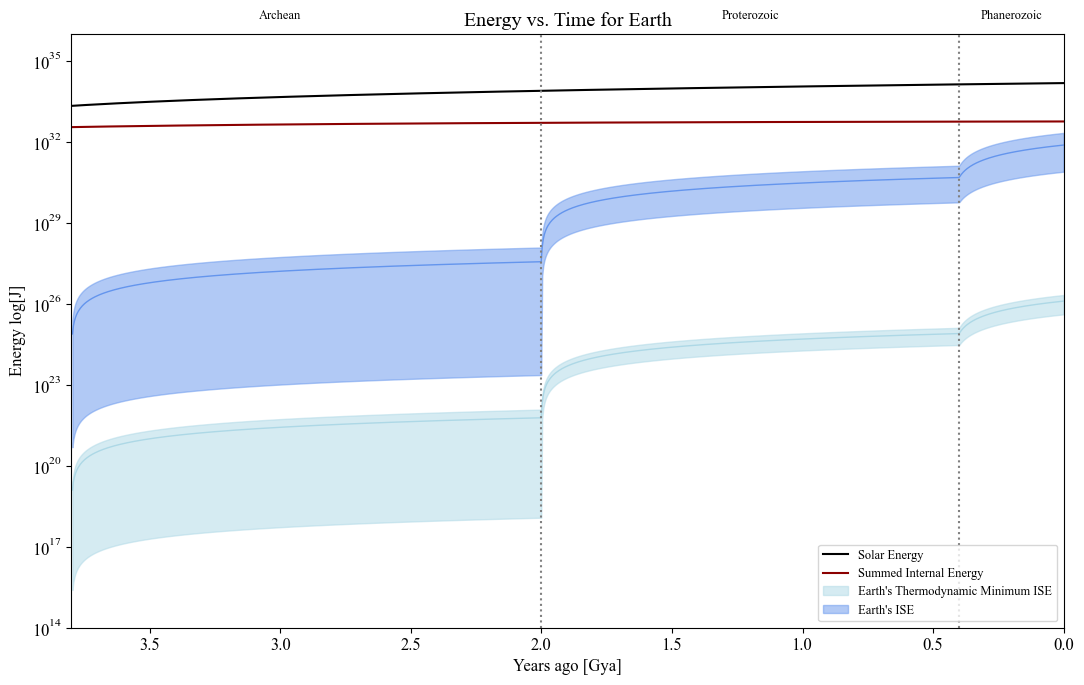

Figure 2 saved. Solar(today) = 1.49e+34 J | Internal(today) = 5.65e+32 J
Biosphere(today, empirical ISE) = 7.56e+31 J
Biosphere(today, thermo min)    = 1.25e+26 J


In [31]:
# ============================================================
# Figure 2 — earth_e.png
# Earth's cumulative energy budget vs time (log y, 3.8 Gya to present)
# Solar (Gough 1981 evolving L), summed internal (accretional+radiogenic+tidal),
# biosphere requirements (empirical + thermodynamic-minimum ISE) with bands.
# ============================================================

# --- Earth row from df_ss ---
earth_row_fig2 = df_ss[df_ss["name"] == "Earth"].iloc[0]
R_e   = float(earth_row_fig2["radius_m"])
d_e   = float(earth_row_fig2["distance_m"])
A_e   = float(earth_row_fig2["albedo"])
M_e   = float(earth_row_fig2["mass_kg"])
f_sil = float(earth_row_fig2["f_sil_estimated"])
star_age_e = float(earth_row_fig2["star_age_Gyr"])

# Time grid: start a tiny offset past ACCRETION_OFFSET to avoid log(0).
t_min_fig2 = ACCRETION_OFFSET_GYR + 1e-3
t_age_gyr_fig2 = np.linspace(t_min_fig2, star_age_e, TIME_STEPS)
years_ago_fig2 = star_age_e - t_age_gyr_fig2

# --- Solar: cumulative absorbed flux with Gough evolution ---
solar_t = np.array([suns_free_energy(R_e, d_e, A_e, t) for t in t_age_gyr_fig2])

# --- Accretional: impulsive at ACCRETION_OFFSET_GYR ---
E_acc = (3.0 / 5.0) * G * M_e**2 / R_e

# --- Radiogenic: integrated decay of BSE-abundance isotopes ---
isotopes = ISOTOPES["isotopes"] if "isotopes" in ISOTOPES else ISOTOPES
def _radiogenic_cumulative(elapsed_yr):
    if elapsed_yr <= 0:
        return 0.0
    total = 0.0
    for _, iso in isotopes.items():
        H_uW    = iso["H_uW_per_kg"]
        lam_yr  = iso["decay_constant_per_Gyr"] / GYR_TO_YR
        C0      = iso["C0_ppm"] * 1e-6
        M_sil   = M_e * f_sil
        P0      = M_sil * C0 * (H_uW * 1e-6)             # W
        E_iso_Wyr = P0 * (1.0 - np.exp(-lam_yr * elapsed_yr)) / lam_yr
        total  += E_iso_Wyr * SEC_PER_YR                  # J
    return total

radiogenic_t = np.array([_radiogenic_cumulative((t - ACCRETION_OFFSET_GYR) * GYR_TO_YR)
                          for t in t_age_gyr_fig2])

# --- Tidal (Earth-Moon) ---
P_tidal_earth = 0.0
moon_row = df_tidal[df_tidal["orbiter"] == "Moon"]
if len(moon_row):
    mr = moon_row.iloc[0]
    P_tidal_earth = compute_tidal_power(
        float(mr["orbitee_mass_kg"]), float(mr["orbiter_radius_m"]),
        float(mr["k2_Q_est"]), float(mr["semi_major_axis_m"]),
        float(mr["eccentricity"]), float(mr["orbital_period_s"]))
tidal_t = P_tidal_earth * (t_age_gyr_fig2 - ACCRETION_OFFSET_GYR) * k_gyr_to_s

internal_t = E_acc + radiogenic_t + tidal_t

# --- Biosphere requirement arrays: convert t_bio (years since life origin) to years-ago ---
years_ago_bio = LIFE_ORIGIN_GYA - np.asarray(t_bio)
# Mask away the first point where biosphere size is 0 (t_bio = 0)
bio_mask = np.asarray(e_changed_ave) > 0

# Apply mask to avoid log(0) in fill_between
def _safe(arr):
    return np.asarray(arr)[bio_mask]

# Plot
fig2, ax2 = plt.subplots(figsize=(11, 7))
ax2.plot(years_ago_fig2, solar_t,    color="black", label="Solar Energy")
ax2.plot(years_ago_fig2, internal_t, color="darkred", label="Summed Internal Energy")
ax2.fill_between(years_ago_bio[bio_mask], _safe(e_changed_min), _safe(e_changed_max),
                 color="lightblue", alpha=0.5, label="Earth's Thermodynamic Minimum ISE")
ax2.plot(years_ago_bio[bio_mask], _safe(e_changed_ave),
         color="lightblue", linewidth=1)
ax2.fill_between(years_ago_bio[bio_mask], _safe(E_all_processes_time_min),
                 _safe(E_all_processes_time_max),
                 color="cornflowerblue", alpha=0.5, label="Earth's ISE")
ax2.plot(years_ago_bio[bio_mask], _safe(E_all_processes_time_ave),
         color="cornflowerblue", linewidth=1)

ax2.axvline(ARCHEAN_END_GYA,         linestyle=":", color="gray")
ax2.axvline(PHANEROZOIC_START_GYA,   linestyle=":", color="gray")
for x, label in [(3.0, "Archean"), (1.2, "Proterozoic"), (0.2, "Phanerozoic")]:
    ax2.text(x, 1.02, label, ha="center", va="bottom", fontsize=9,
             transform=ax2.get_xaxis_transform())

ax2.set_yscale("log")
ax2.set_xlim(LIFE_ORIGIN_GYA, 0)
ax2.set_ylim(1e14, 1e36)
ax2.set_xlabel("Years ago [Gya]")
ax2.set_ylabel("Energy log[J]")
ax2.set_title("Energy vs. Time for Earth")
ax2.legend(loc="lower right", fontsize=9)

fig2.tight_layout()
fig2.savefig("plots/earth_e.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Figure 2 saved. Solar(today) = {solar_t[-1]:.2e} J | Internal(today) = {internal_t[-1]:.2e} J")
print(f"Biosphere(today, empirical ISE) = {E_all_processes_time_ave[-1]:.2e} J")
print(f"Biosphere(today, thermo min)    = {e_changed_ave[-1]:.2e} J")
